<a href="https://colab.research.google.com/github/sjlee53/ESAA-submission/blob/main/project/0923_ESAA_YB_movie_visualization_all.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESAA YB 미니프로젝트 1 — 영화 관객수 시각화 (통합본)

DACON 영화 관객수 데이터(2010~2015년 한국영화 600편)로 열한 가지 가설을 검증한다.

## 공통 구조

모든 분석은 같은 순서를 따른다.

> **가설** → **단계별 검증** → **시각화** → **해석**(결과 + 한계)

단계 수는 주제마다 다르지만, 마지막 단계는 대부분 **교란변수 통제**다.
겉보기 차이가 다른 변수 때문에 생긴 것은 아닌지 확인하는 과정이다.

## 목차

| 번호 | 주제 | 담당 | 결론 요약 |
|---|---|---|---|
| 1 | 수요일 개봉작은 관객이 많은가 | 김민서 | 173배 차이는 대부분 제작 규모 때문 |
| 2 | 계절은 개봉 성적을 설명하는가 | 김희경 | 겨울이 아니라 1월, 그것도 규모 때문 |
| 3 | 작은 영화일수록 상영시간이 딱 떨어지는가 | 이승주 | 경향은 있으나 통계적으로는 경계선 |
| 4 | 장르별 제작 규모와 흥행 하한선 | 황경서 | 대규모 안에서도 장르가 하한선을 가름 |
| 5 | 제작 규모별 관객수 분포 | 김민서 | 쌍봉 분포가 규모로 설명됨 (R²=0.562) |
| 6 | 인력과 관객 사이에 문턱이 있는가 | 이승주 | 스태프 117~279명 구간에 증가가 몰림 |
| 7 | 수치형 변수와 관객수의 관계 | 김민서 | 스태프가 가장 강하고, 상영시간은 그 그림자 |
| 8 | 제작 규모에 따라 장르 영향력이 달라지는가 | 이승주 | 대규모에서 장르 차이가 가장 작음 |
| 9 | 감독 경력은 흥행을 만드는가 | 김희경 | 경력이 아니라 규모가 만든다 |
| 10 | 상영시간과 스태프 수의 관계 | 황경서 | 선형이 아니라 120분 이후 둔화 |
| 11 | 관람등급 구성은 어떻게 변했는가 | 김희경 | 구성이 아니라 장르 내부에서 변함 |

---

## 0. 준비

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

url = 'https://raw.githubusercontent.com/sjlee53/ESAA-submission/main/project/data/movies_train.csv'
df = pd.read_csv(url)
print(df.shape)
df.head()

(600, 12)


,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


In [2]:
# 코랩 한글 폰트 (한 번만 실행)
!apt-get -qq install fonts-nanum
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'NanumGothic'   # seaborn이 폰트를 덮으므로 set_style 뒤에
plt.rcParams['axes.unicode_minus'] = False

Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


### 전처리 (열한 개 분석 공통)

여기서 만든 파생변수를 이후 모든 분석에서 함께 쓴다.

- **제작 규모**: 제작비 변수가 없어 **스태프 수를 대리 지표**로 사용한다. 그래서 이 문서는
  "제작비"가 아니라 **"제작 규모"**라고 쓴다.
- **`dir_prev_bfnum`의 결측 330개**는 `dir_prev_num == 0`인 행과 정확히 일치한다.
  빠진 값이 아니라 *전작이 없어서 존재할 수 없는 값*이므로 0으로 채운다. (9번에서 자세히 다룸)

In [3]:
# 날짜
df['release_time'] = pd.to_datetime(df['release_time'])
df['연도'] = df['release_time'].dt.year
df['월'] = df['release_time'].dt.month
df['요일'] = df['release_time'].dt.day_name()

# 계절
계절맵 = {12: '겨울', 1: '겨울', 2: '겨울', 3: '봄', 4: '봄', 5: '봄',
        6: '여름', 7: '여름', 8: '여름', 9: '가을', 10: '가을', 11: '가을'}
df['계절'] = df['월'].map(계절맵)

# 감독 (전작이 없으면 신인)
df['dir_prev_bfnum'] = df['dir_prev_bfnum'].fillna(0)
df['감독'] = np.where(df['dir_prev_num'] == 0, '신인', '경력')

# 제작 규모 (스태프 수 기준)
df['규모'] = pd.cut(df['num_staff'], [-1, 80, 250, 900],
                  labels=['소(~80명)', '중(81~250명)', '대(251명~)'])

# 관객수 로그 (분포가 오른쪽으로 크게 치우쳐 있음)
df['log관객수'] = np.log10(df['box_off_num'])

# 관람등급
df['청불'] = df['screening_rat'] == '청소년 관람불가'

# 자주 쓰는 순서
규모목록 = ['소(~80명)', '중(81~250명)', '대(251명~)']
계절목록 = ['봄', '여름', '가을', '겨울']
주요장르 = ['드라마', '다큐멘터리', '멜로/로맨스', '코미디', '공포', '액션', '느와르']

df[['title', 'genre', 'time', 'num_staff', '규모', '계절', 'box_off_num']].head()

,title,genre,time,num_staff,규모,계절,box_off_num
0,개들의 전쟁,액션,96,91,중(81~250명),가을,23398
1,내부자들,느와르,130,387,대(251명~),가을,7072501
2,은밀하게 위대하게,액션,123,343,대(251명~),여름,6959083
3,나는 공무원이다,코미디,101,20,소(~80명),여름,217866
4,불량남녀,코미디,108,251,대(251명~),가을,483387


---

# 1. 수요일 개봉작은 관객이 많은가 · 김민서

**가설**: 수요일에 개봉한 영화가 목요일 개봉작보다 관객이 많을 것이다.

한국 영화는 목요일 개봉이 표준이다. 그런데 일부 작품만 수요일에 개봉한다.
그 차이가 실제 성적으로 이어지는지 확인한다.

### 1단계. 요일별로 얼마나 차이 나는가

In [4]:
요일집계 = df.groupby('요일').agg(
    편수=('title', 'size'),
    관객중앙=('box_off_num', 'median'),
    스태프중앙=('num_staff', 'median'))

순서 = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
print(요일집계.reindex(순서).to_string())

수 = df[df['요일'] == 'Wednesday']
목 = df[df['요일'] == 'Thursday']
배수 = 수['box_off_num'].median() / 목['box_off_num'].median()
print()
print('수요일 {}편 {:,.0f}명  /  목요일 {}편 {:,.0f}명  = {:.1f}배'.format(
    len(수), 수['box_off_num'].median(), len(목), 목['box_off_num'].median(), 배수))

              편수       관객중앙  스태프중앙
요일                                
Monday       4.0      440.5    7.0
Tuesday      2.0  2591569.0  116.0
Wednesday  107.0  1025243.0  331.0
Thursday   484.0     5921.5   61.0
Friday       2.0    48651.0   50.0
Saturday     1.0      353.0   41.0
Sunday       NaN        NaN    NaN

수요일 107편 1,025,243명  /  목요일 484편 5,922명  = 173.1배


### 2단계. 우연인가 — 맨-휘트니 검정

관객수 분포가 정규분포와 거리가 멀어서, 평균 대신 **순위**를 비교하는 맨-휘트니 검정을 쓴다.

In [5]:
통계량, p값 = stats.mannwhitneyu(수['box_off_num'], 목['box_off_num'],
                               alternative='two-sided')
print('맨-휘트니 p = %.6f' % p값)

맨-휘트니 p = 0.000000


### 3단계. 제작 규모 때문은 아닌가 — 교란변수 통제

수요일 개봉작의 스태프 수 중앙값이 목요일의 5배가 넘는다.
**요일이 아니라 규모 때문**일 수 있으므로 규모를 고정하고 다시 본다.

In [6]:
수목 = df[df['요일'].isin(['Wednesday', 'Thursday'])]

print('[규모 구성 (%)]')
print((pd.crosstab(수목['요일'], 수목['규모'], normalize='index') * 100).round(1).to_string())
print()

print('[규모를 고정하고 다시 비교]')
for 규모 in 규모목록:
    a = 수목[(수목['규모'] == 규모) & (수목['요일'] == 'Wednesday')]['box_off_num']
    b = 수목[(수목['규모'] == 규모) & (수목['요일'] == 'Thursday')]['box_off_num']
    print('  %-12s 수 %2d편 %9.0f  /  목 %3d편 %9.0f  = %5.1f배'
          % (규모, len(a), a.median(), len(b), b.median(), a.median() / b.median()))

[규모 구성 (%)]
규모         소(~80명)  중(81~250명)  대(251명~)
요일                                      
Thursday      55.4        25.2      19.4
Wednesday     21.5        12.1      66.4

[규모를 고정하고 다시 비교]
  소(~80명)      수 23편      2146  /  목 268편      1850  =   1.2배
  중(81~250명)   수 13편    867386  /  목 122편     12943  =  67.0배
  대(251명~)     수 71편   1646142  /  목  94편    849407  =   1.9배


### 4단계. 그럼 왜 수요일에 개봉하나 — 성수기와 겹치는가

의도는 데이터로 확인할 수 없다. 대신 **언제 개봉했는지**는 확인할 수 있다.

In [7]:
성수기 = [1, 7, 8, 12]
print('성수기(1·7·8·12월) 개봉 비율')
print('  수요일 %.1f%%   목요일 %.1f%%'
      % (수['월'].isin(성수기).mean() * 100, 목['월'].isin(성수기).mean() * 100))
print()
print('수요일 개봉작의 월별 편수')
print(수['월'].value_counts().sort_index().to_string())

성수기(1·7·8·12월) 개봉 비율
  수요일 55.1%   목요일 26.2%

수요일 개봉작의 월별 편수
월
1     15
2      2
4      7
5      7
6      3
7     14
8     14
9      9
10    12
11     8
12    16


### 시각화

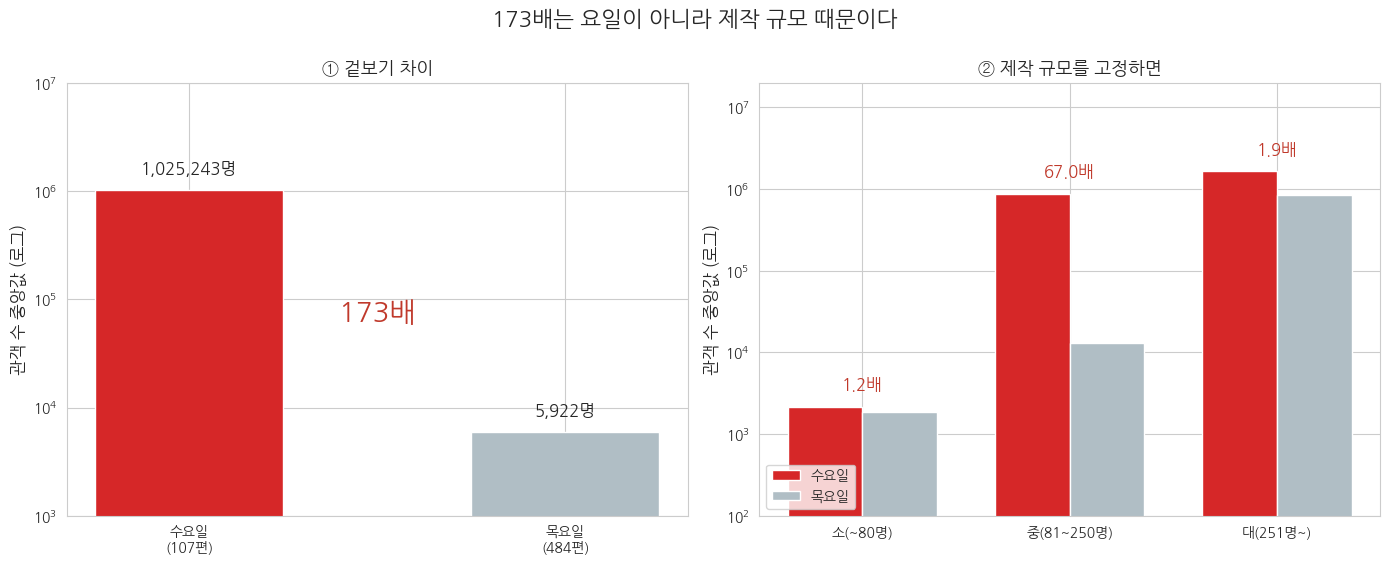

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))

# ── 왼쪽: 전체 비교 ──
ax = axes[0]
중앙값 = [수['box_off_num'].median(), 목['box_off_num'].median()]
막대 = ax.bar(['수요일\n(%d편)' % len(수), '목요일\n(%d편)' % len(목)],
             중앙값, color=['#d62728', '#b0bec5'], width=0.5)
ax.set_yscale('log')          # 축만 로그로 → 눈금에 실제 관객수가 찍힘
for 막, v in zip(막대, 중앙값):
    ax.text(막.get_x() + 막.get_width() / 2, v * 1.4, '{:,.0f}명'.format(v),
            ha='center', fontsize=12, fontweight='bold')
ax.text(0.5, 0.45, '%.0f배' % 배수, transform=ax.transAxes, ha='center',
        fontsize=20, fontweight='bold', color='#c0392b')
ax.set_ylim(1e3, 1e7)
ax.set_ylabel('관객 수 중앙값 (로그)', fontsize=12)
ax.set_title('① 겉보기 차이', fontsize=13)

# ── 오른쪽: 규모 고정 후 ──
ax = axes[1]
x = np.arange(3)
w = 0.36
수값, 목값 = [], []
for 규모 in 규모목록:
    수값.append(수목[(수목['규모'] == 규모) & (수목['요일'] == 'Wednesday')]['box_off_num'].median())
    목값.append(수목[(수목['규모'] == 규모) & (수목['요일'] == 'Thursday')]['box_off_num'].median())

ax.bar(x - w / 2, 수값, w, label='수요일', color='#d62728')
ax.bar(x + w / 2, 목값, w, label='목요일', color='#b0bec5')
ax.set_yscale('log')
for i in range(3):
    ax.text(i, max(수값[i], 목값[i]) * 1.6, '%.1f배' % (수값[i] / 목값[i]),
            ha='center', fontsize=12, fontweight='bold', color='#c0392b')
ax.set_xticks(x)
ax.set_xticklabels(규모목록, fontsize=10)
ax.set_ylim(1e2, 2e7)
ax.set_ylabel('관객 수 중앙값 (로그)', fontsize=12)
ax.set_title('② 제작 규모를 고정하면', fontsize=13)
ax.legend(fontsize=10, loc='lower left')

fig.suptitle('173배는 요일이 아니라 제작 규모 때문이다', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

**해석**

수요일 개봉작 107편의 관객수 중앙값은 1,025,243명, 목요일 484편은 5,922명으로
**173배** 차이가 난다. 맨-휘트니 검정에서도 우연으로 보기 어렵다.

그러나 **수요일 개봉작의 66.4%가 대규모**인 반면 목요일은 19.4%다. 제작 규모를 고정하면
소규모 1.2배, 대규모 1.9배로 **173배가 사실상 사라진다**. 중규모만 67배로 크게 남지만
수요일 13편뿐이라 불안정하다.

즉 **수요일에 개봉해서 흥행한 것이 아니라, 수요일에 대작을 넣는 것**이다.

왜 그럴까. 의도는 확인할 수 없지만 시기는 확인된다. 수요일 개봉작의 **55.1%가
1·7·8·12월(성수기)**인 반면 목요일은 26.2%다. 연휴·방학을 앞두고 하루 먼저 여는
전략으로 보인다.

**한계**: 스태프 수를 제작 규모의 대리 지표로 썼다. 또 개봉 요일을 정하는 것은 배급사의
선택이므로, 요일과 규모 중 무엇이 먼저인지는 이 데이터로 가릴 수 없다.

---

# 2. 계절은 개봉 성적을 설명하기 좋은 단위인가 · 김희경

**가설**: 개봉 계절에 따라 관객수가 달라질 것이다.

계절은 흔히 쓰는 단위지만, **묶는 단위가 적절한지**부터 의심해 본다.

### 1단계. 계절별 관객수

관객수는 소수의 대박 영화가 평균을 끌어올리므로 **중앙값**으로 비교한다.
계절 간 차이는 순위를 비교하는 **크러스컬-왈리스 검정**으로 확인한다.

In [9]:
계절집계 = df.groupby('계절').agg(편수=('title', 'size'),
                              관객중앙=('box_off_num', 'median')).reindex(계절목록)
print(계절집계.to_string())

그룹 = []
for 계절 in 계절목록:
    그룹.append(df[df['계절'] == 계절]['box_off_num'])
print()
print('크러스컬-왈리스 p = %.4f' % stats.kruskal(*그룹)[1])

     편수     관객중앙
계절              
봄   156   5942.5
여름  133  13886.0
가을  192  18618.5
겨울  119  27083.0

크러스컬-왈리스 p = 0.0279


### 2단계. 겨울의 높은 관객수는 어디서 오는가

계절은 세 달을 묶은 단위다. 겨울 전체가 높은 것인지, **특정 달만 높은 것**인지 쪼개 본다.

In [10]:
월집계 = df.groupby('월').agg(편수=('title', 'size'), 관객중앙=('box_off_num', 'median'))
print(월집계.to_string())

일월 = df[df['월'] == 1]['box_off_num']
그외 = df[df['월'] != 1]['box_off_num']
십이이월 = df[df['월'].isin([12, 2])]['box_off_num']
비겨울 = df[df['계절'] != '겨울']['box_off_num']

print()
print('1월 %d편 %.0f  vs  그 외 %d편 %.0f   (%.1f배)  p = %.4f'
      % (len(일월), 일월.median(), len(그외), 그외.median(),
         일월.median() / 그외.median(), stats.mannwhitneyu(일월, 그외)[1]))
print('12·2월 %d편 %.0f  vs  겨울 아닌 달 %d편 %.0f            p = %.4f'
      % (len(십이이월), 십이이월.median(), len(비겨울), 비겨울.median(),
         stats.mannwhitneyu(십이이월, 비겨울)[1]))

    편수      관객중앙
월               
1   39  283449.0
2   31   10203.0
3   52    4110.5
4   47    7956.0
5   57    7448.0
6   29   18343.0
7   49    9301.0
8   55   16248.0
9   60   14931.0
10  60   45112.0
11  72   15813.0
12  49    9323.0

1월 39편 283449  vs  그 외 561편 11650   (24.3배)  p = 0.0269
12·2월 80편 9763  vs  겨울 아닌 달 481편 11666            p = 0.1871


### 3단계. 1월 효과는 매년 반복되는가

1월은 39편뿐이다. **특정 연도의 흥행작 때문**에 높아진 것은 아닌지 연도별로 쪼갠다.

In [11]:
for 연도 in sorted(df['연도'].unique()):
    해 = df[df['연도'] == 연도]
    a = 해[해['월'] == 1]['box_off_num']
    b = 해[해['월'] != 1]['box_off_num']
    순위 = 해.groupby('월')['box_off_num'].median().rank(ascending=False)[1]
    print('%d  1월 %d편 %10.0f  /  그 외 %3d편 %8.0f  = %6.1f배   12개월 중 %.0f위'
          % (연도, len(a), a.median(), len(b), b.median(),
             a.median() / b.median(), 순위))

2010  1월 8편      85270  /  그 외  82편    26448  =    3.2배   12개월 중 5위
2011  1월 4편    1371404  /  그 외  76편    17118  =   80.1배   12개월 중 1위
2012  1월 5편     467697  /  그 외  83편    13429  =   34.8배   12개월 중 2위
2013  1월 4편    3583886  /  그 외  91편    14188  =  252.6배   12개월 중 1위
2014  1월 9편     479280  /  그 외 118편     7584  =   63.2배   12개월 중 1위
2015  1월 9편     151550  /  그 외 111편     6226  =   24.3배   12개월 중 1위


### 4단계. 장르 구성 때문은 아닌가

1월에 흥행 장르가 몰려 있을 수 있다. (주요 7개 장르 기준, 1월 38편 / 그 외 504편)

In [12]:
sub = df[df['genre'].isin(주요장르)].copy()
sub['1월여부'] = np.where(sub['월'] == 1, '1월', '그 외')

표 = pd.crosstab(sub['1월여부'], sub['genre'])
print((pd.crosstab(sub['1월여부'], sub['genre'], normalize='index') * 100).round(1).to_string())
print()
print('편수: 1월 %d편 / 그 외 %d편' % (표.loc['1월'].sum(), 표.loc['그 외'].sum()))
print('장르 구성 카이제곱 p = %.4f' % stats.chi2_contingency(표)[1])

genre   공포  느와르  다큐멘터리   드라마  멜로/로맨스   액션   코미디
1월여부                                           
1월     2.6  2.6   15.8  42.1    10.5  5.3  21.1
그 외    8.1  5.2   17.3  40.7    14.7  5.2   8.9

편수: 1월 38편 / 그 외 504편
장르 구성 카이제곱 p = 0.2662


### 5단계. 제작 규모 때문은 아닌가 — 교란변수 통제

1월 개봉작이 애초에 대작이라면, 높은 관객수는 **1월이 아니라 규모** 때문이다.

In [13]:
df['1월여부'] = np.where(df['월'] == 1, '1월', '그 외')

print(df.groupby('1월여부').agg(
    편수=('title', 'size'),
    스태프중앙=('num_staff', 'median'),
    대규모비율=('규모', lambda s: round((s == '대(251명~)').mean() * 100, 1))).to_string())
print()

print('[규모를 고정하고 다시 비교]')
for 규모 in 규모목록:
    a = df[(df['규모'] == 규모) & (df['1월여부'] == '1월')]['box_off_num']
    b = df[(df['규모'] == 규모) & (df['1월여부'] == '그 외')]['box_off_num']
    print('  %-12s 1월 %2d편 %9.0f  /  그 외 %3d편 %8.0f  = %5.2f배'
          % (규모, len(a), a.median(), len(b), b.median(), a.median() / b.median()))

       편수  스태프중앙  대규모비율
1월여부                   
1월     39  200.0   46.2
그 외   561   78.0   26.2

[규모를 고정하고 다시 비교]
  소(~80명)      1월 15편      2951  /  그 외 282편     1782  =  1.66배
  중(81~250명)   1월  6편    155266  /  그 외 132편    17155  =  9.05배
  대(251명~)     1월 18편   1350642  /  그 외 147편  1169546  =  1.15배


### 시각화

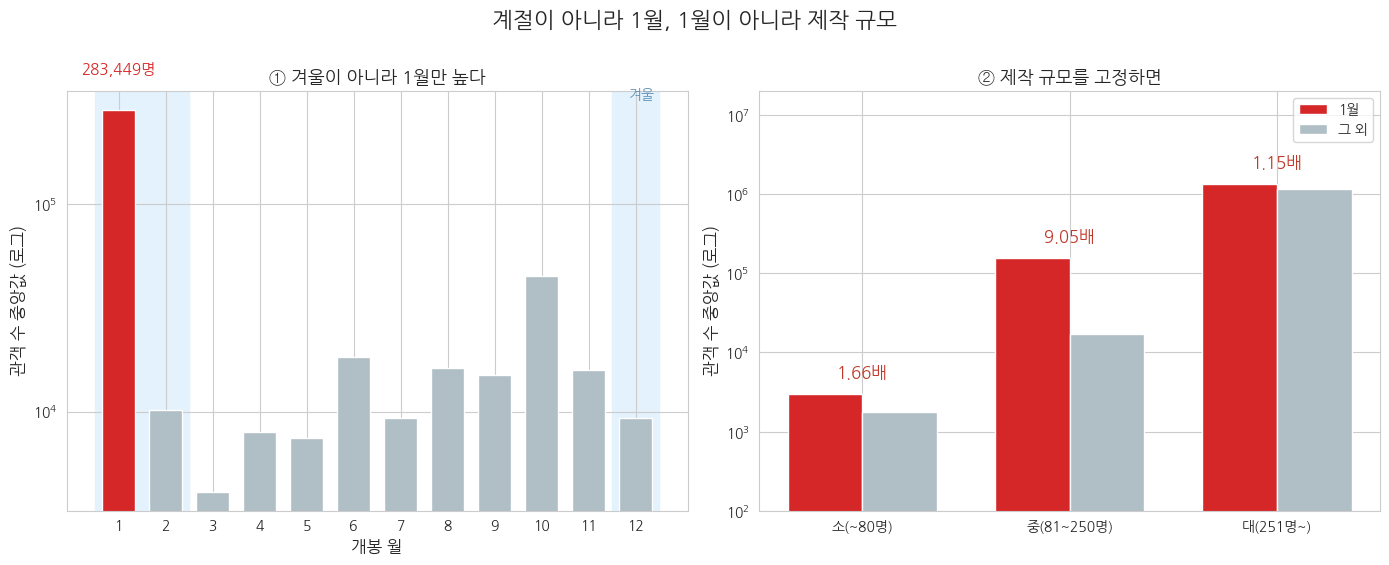

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))

# ── 왼쪽: 월별 관객수 (1월만 강조, 겨울 배경) ──
ax = axes[0]
월중앙 = df.groupby('월')['box_off_num'].median()
색 = []
for 월 in range(1, 13):
    색.append('#d62728' if 월 == 1 else '#b0bec5')

ax.axvspan(0.5, 2.5, color='#e3f2fd', zorder=0)      # 1·2월
ax.axvspan(11.5, 12.5, color='#e3f2fd', zorder=0)    # 12월
ax.bar(월중앙.index, 월중앙.values, color=색, width=0.7, zorder=2)
ax.set_yscale('log')
ax.text(12.4, 3.2e5, '겨울', fontsize=10, color='#5c8fb5', ha='right')
ax.text(1, 월중앙[1] * 1.5, '{:,.0f}명'.format(월중앙[1]),
        ha='center', fontsize=11, fontweight='bold', color='#d62728')
ax.set_xticks(range(1, 13))
ax.set_xlabel('개봉 월', fontsize=12)
ax.set_ylabel('관객 수 중앙값 (로그)', fontsize=12)
ax.set_title('① 겨울이 아니라 1월만 높다', fontsize=13)

# ── 오른쪽: 규모 고정 후 ──
ax = axes[1]
x = np.arange(3)
w = 0.36
일월값, 그외값 = [], []
for 규모 in 규모목록:
    일월값.append(df[(df['규모'] == 규모) & (df['1월여부'] == '1월')]['box_off_num'].median())
    그외값.append(df[(df['규모'] == 규모) & (df['1월여부'] == '그 외')]['box_off_num'].median())

ax.bar(x - w / 2, 일월값, w, label='1월', color='#d62728')
ax.bar(x + w / 2, 그외값, w, label='그 외', color='#b0bec5')
ax.set_yscale('log')
for i in range(3):
    ax.text(i, max(일월값[i], 그외값[i]) * 1.6, '%.2f배' % (일월값[i] / 그외값[i]),
            ha='center', fontsize=12, fontweight='bold', color='#c0392b')
ax.set_xticks(x)
ax.set_xticklabels(규모목록, fontsize=10)
ax.set_ylim(1e2, 2e7)
ax.set_ylabel('관객 수 중앙값 (로그)', fontsize=12)
ax.set_title('② 제작 규모를 고정하면', fontsize=13)
ax.legend(fontsize=10)

fig.suptitle('계절이 아니라 1월, 1월이 아니라 제작 규모', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

**해석**

계절별 관객수 중앙값은 봄 5,943명, 여름 13,886명, 가을 18,619명, 겨울 27,083명으로
겨울이 가장 높다(p=0.028). 그러나 겨울을 월로 쪼개면 **1월만 283,449명**이고
12·2월은 평범하다. 12·2월을 합친 중앙값(9,763명)은 겨울이 아닌 달(11,666명)보다도
낮고, 차이도 유의하지 않다(p=0.187). 즉 **"겨울이 높다"가 아니라 "1월이 높다"**가 정확하다.

1월 효과는 연도마다 반복된다. 다만 2010년만 3.2배로 12개월 중 5위이고, 나머지
2011~2015년이 24~253배로 뚜렷하다.

장르 구성 때문은 아니다(p=0.266). 그러나 **제작 규모로는 상당 부분 설명된다.**
1월 개봉작의 스태프 중앙값은 200명으로 그 외 달(78명)의 2.6배이고, 46.2%가 대규모다.
규모를 고정하면 24배가 **소 1.7배, 대 1.15배**로 줄어든다.

**결론: 1월에 개봉해서 흥행한 것이 아니라, 1월에 대작을 넣는다.**

**한계**: 배수 자체는 해석하지 않는 편이 좋다. 2013년 1월은 4편뿐이라 중앙값
3,583,886명이 「베드」(660명)와 「베를린」(717만 명)의 평균이다. 편수가 적으면
중앙값이 중심을 나타내지 못한다. 중규모 9.0배도 1월 6편에 기대고 있다.

---

# 3. 작은 영화일수록 상영시간이 딱 떨어지는가 · 이승주

**가설**: 제작 규모가 작은 영화일수록 상영시간이 90분·95분처럼 5의 배수에 몰릴 것이다.

상영시간이 5로 끝날 이유는 없다. 그런데도 쏠림이 있다면 실제 길이가 아니라
**기재 방식**이 남긴 흔적일 수 있다.

### 1단계. 전체에 쏠림이 있는가 — 기준선과 비교

상영시간이 무작위라면 5의 배수는 20%, 10의 배수는 10%여야 한다.

먼저 **"5의 배수인가?"를 True/False 열로 만들어 둔다.** True를 1, False를 0으로 보고
평균을 내면 그게 곧 비율이라 이후 계산이 간단해진다.

In [15]:
df['배수5'] = (df['time'] % 5 == 0)
df['배수10'] = (df['time'] % 10 == 0)

print('5의 배수 : %.1f%%  (무작위면 20%%)' % (df['배수5'].mean() * 100))
print('10의 배수: %.1f%%  (무작위면 10%%)' % (df['배수10'].mean() * 100))
print()
print('가장 흔한 상영시간 10개')
print(df['time'].value_counts().head(10).to_string())

5의 배수 : 24.7%  (무작위면 20%)
10의 배수: 12.2%  (무작위면 10%)

가장 흔한 상영시간 10개
time
90     17
100    17
98     16
89     15
91     15
114    15
95     15
97     15
104    14
99     14


### 2단계. 제작 규모에 따라 갈리는가

In [16]:
규모별 = df.groupby('규모', observed=True).agg(
    편수=('배수5', 'size'),
    배수5비율=('배수5', 'mean'),
    배수10비율=('배수10', 'mean'),
    상영시간중앙=('time', 'median'))
규모별['배수5비율'] = (규모별['배수5비율'] * 100).round(1)
규모별['배수10비율'] = (규모별['배수10비율'] * 100).round(1)
규모별

,편수,배수5비율,배수10비율,상영시간중앙
규모,,,,
소(~80명),297,28.3,14.1,91.0
중(81~250명),138,23.9,11.6,102.0
대(251명~),165,18.8,9.1,115.0


### 3단계. 0 때문인가 5 때문인가 — 끝자리를 펼쳐서 확인

In [17]:
df['끝자리'] = df['time'] % 10
(pd.crosstab(df['규모'], df['끝자리'], normalize='index') * 100).round(1)

끝자리,0,1,2,3,4,5,6,7,8,9
규모,,,,,,,,,,
소(~80명),14.1,7.4,8.4,9.1,9.8,14.1,6.7,11.1,10.1,9.1
중(81~250명),11.6,8.7,10.1,8.7,11.6,12.3,9.4,9.4,8.0,10.1
대(251명~),9.1,12.7,12.1,6.1,15.2,9.7,5.5,11.5,6.7,11.5


### 4단계. 우연인가 — 카이제곱 검정

In [18]:
tab = pd.crosstab(df['규모'], df['배수5'])
print(tab.to_string())
print()
print('소·중·대 전체 p = %.4f' % stats.chi2_contingency(tab)[1])
print('소 vs 대    p = %.4f' % stats.chi2_contingency(tab.iloc[[0, 2]])[1])

배수5         False  True 
규모                      
소(~80명)       213     84
중(81~250명)    105     33
대(251명~)      134     31

소·중·대 전체 p = 0.0742
소 vs 대    p = 0.0316


### 5단계. 차이의 크기 — 관측 편수 vs 기대 편수

In [19]:
for 규모 in 규모목록:
    d = df[df['규모'] == 규모]
    관측 = d['배수5'].sum()
    기대 = len(d) * 0.2
    print('%-12s %3d편 중 5의 배수 %2d편  (기대 %4.1f편, 차이 %+.1f)'
          % (규모, len(d), 관측, 기대, 관측 - 기대))

소(~80명)      297편 중 5의 배수 84편  (기대 59.4편, 차이 +24.6)
중(81~250명)   138편 중 5의 배수 33편  (기대 27.6편, 차이 +5.4)
대(251명~)     165편 중 5의 배수 31편  (기대 33.0편, 차이 -2.0)


### 6단계. 장르 구성 때문은 아닌가 — 교란변수 통제

소규모에는 다큐멘터리가 90편 있지만 중규모에는 3편, 대규모에는 0편이다.
그런데 **다큐멘터리는 원래 5의 배수 비율이 높다.**

In [20]:
장르별 = df.groupby('genre').agg(편수=('배수5', 'size'), 배수5비율=('배수5', 'mean'))
장르별['배수5비율'] = (장르별['배수5비율'] * 100).round(1)
print(장르별.sort_values('배수5비율', ascending=False).to_string())

         편수  배수5비율
genre             
SF       13   46.2
뮤지컬       5   40.0
코미디      53   34.0
애니메이션    21   33.3
다큐멘터리    93   32.3
느와르      27   25.9
드라마     221   23.1
멜로/로맨스   78   17.9
미스터리     17   17.6
공포       42   14.3
액션       28   14.3
서스펜스      2    0.0


In [21]:
def 배수5비율_출력(데이터, 라벨):
    print('[%s]' % 라벨)
    for 규모 in 규모목록:
        d = 데이터[데이터['규모'] == 규모]
        print('  %-12s %3d편   %.1f%%' % (규모, len(d), d['배수5'].mean() * 100))
    print()


배수5비율_출력(df, '전체')
배수5비율_출력(df[df['genre'] != '다큐멘터리'], '다큐멘터리 제외')
배수5비율_출력(df[df['genre'] == '드라마'], '드라마만')

[전체]
  소(~80명)      297편   28.3%
  중(81~250명)   138편   23.9%
  대(251명~)     165편   18.8%

[다큐멘터리 제외]
  소(~80명)      207편   26.6%
  중(81~250명)   135편   23.7%
  대(251명~)     165편   18.8%

[드라마만]
  소(~80명)       94편   27.7%
  중(81~250명)    66편   24.2%
  대(251명~)      61편   14.8%



### 시각화

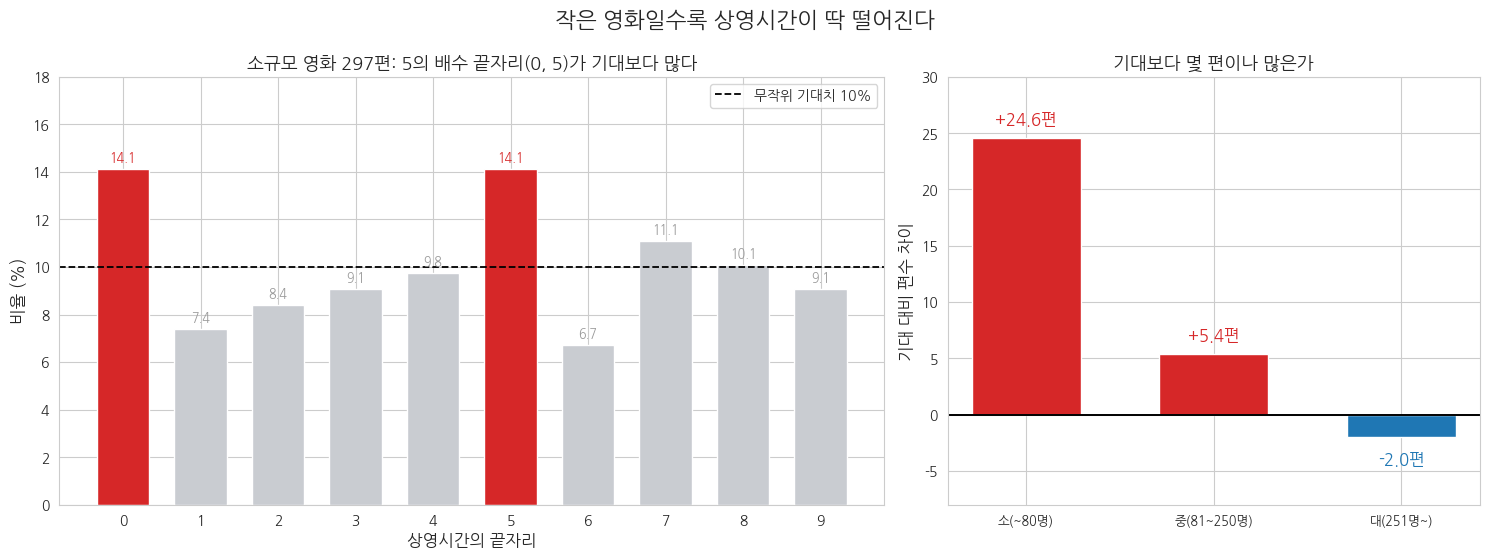

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6),
                         gridspec_kw={'width_ratios': [1.55, 1]})

# ── 왼쪽: 소규모 끝자리 분포 ──
소 = df[df['규모'] == '소(~80명)']
비율 = 소['끝자리'].value_counts(normalize=True).reindex(range(10), fill_value=0) * 100

색 = []
for i in range(10):
    색.append('#d62728' if i in [0, 5] else '#c9ccd1')

axes[0].bar(비율.index, 비율.values, color=색, width=0.68)
axes[0].axhline(10, color='black', linestyle='--', linewidth=1.3, label='무작위 기대치 10%')
for i in range(10):
    글자색 = '#d62728' if i in [0, 5] else '#999'
    axes[0].text(i, 비율[i] + 0.3, '%.1f' % 비율[i], ha='center', fontsize=9, color=글자색)
axes[0].set_xticks(range(10))
axes[0].set_xlabel('상영시간의 끝자리', fontsize=12)
axes[0].set_ylabel('비율 (%)', fontsize=12)
axes[0].set_title('소규모 영화 %d편: 5의 배수 끝자리(0, 5)가 기대보다 많다' % len(소), fontsize=13)
axes[0].set_ylim(0, 18)
axes[0].legend(loc='upper right', fontsize=10)

# ── 오른쪽: 관측 - 기대 편수 ──
차이 = []
for 규모 in 규모목록:
    d = df[df['규모'] == 규모]
    차이.append(d['배수5'].sum() - len(d) * 0.2)

색2 = []
for v in 차이:
    색2.append('#d62728' if v > 0 else '#1f77b4')

axes[1].bar(range(3), 차이, color=색2, width=0.58)
axes[1].axhline(0, color='black', linewidth=1.4)
for i in range(3):
    위치 = 차이[i] + 1.2 if 차이[i] > 0 else 차이[i] - 2.4
    axes[1].text(i, 위치, '%+.1f편' % 차이[i], ha='center',
                 fontsize=12, fontweight='bold', color=색2[i])
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(규모목록, fontsize=9)
axes[1].set_ylabel('기대 대비 편수 차이', fontsize=12)
axes[1].set_title('기대보다 몇 편이나 많은가', fontsize=13)
axes[1].set_ylim(-8, 30)

fig.suptitle('작은 영화일수록 상영시간이 딱 떨어진다', fontsize=16, y=0.99)
plt.tight_layout()
plt.show()

**해석**

소규모 영화는 상영시간 끝자리 0과 5가 각각 14.1%로 가장 높다. 나머지 여덟 자리는
6.7~11.1%에 흩어져 있다. 두 자리가 동시에 솟았다는 것은 "5 단위로 끊어 적는다"는
하나의 원인을 가리킨다.

기대치 대비 편수로 보면 소 **+24.6편**, 중 +5.4편, 대 **−2.0편**이다. 규모가 커질수록
줄어들고, 대규모는 오히려 기준치보다 적다.

**장르 구성 때문은 아니다.** 소규모에는 5의 배수 비율이 높은 다큐멘터리(32.3%)가 90편
몰려 있지만, 다큐를 빼도 소 26.6% / 중 23.7% / 대 18.8%로 순서가 유지되고,
드라마만 봐도 소 27.7% / 중 24.2% / 대 14.8%로 같다.

실제 길이가 그런 것이 아니라 **작은 영화일수록 상영시간을 반올림해서 기재했을 가능성**이 크다.

**한계**: 소 vs 대는 p=0.032로 유의하지만 세 그룹 전체로는 **p=0.074**로 0.05를 넘지 못한다.
확정이 아니라 **경향**으로 보아야 한다. 또 0·5가 높은 것은 사실이나 대규모의 4(15.2%)처럼
다른 자리도 흔들리므로 "0과 5만 솟는다"고까지는 말할 수 없다. "반올림했다"도 추론이다.

---

# 4. 장르별 제작 규모와 흥행 하한선 · 황경서

**가설**: 장르에 따라 대규모로 제작되는 비율이 다르고, 대규모 안에서도 흥행 결과가 다를 것이다.

"장르마다 스태프 수가 다르다"는 것만으로는 새로운 사실이 아니다.
그 차이가 **흥행 결과로 이어지는지**까지 확인한다.

### 1단계. 대규모 영화는 몇 명부터인가 — 기준 확인

이 문서는 전처리에서 만든 공통 기준(**스태프 251명 이상**)을 그대로 쓴다.
다른 분석과 같은 잣대를 대야 결과를 서로 이어 볼 수 있기 때문이다.

251명이 임의로 보일 수 있으므로, 데이터에서 도출되는 **75퍼센타일(264명)**로 바꿔도
결론이 같은지 함께 확인한다.

In [23]:
df['대규모'] = df['규모'] == '대(251명~)'

print('공통 기준 : 스태프 251명 이상 → %d편 (%.1f%%)'
      % (df['대규모'].sum(), df['대규모'].mean() * 100))
print('75퍼센타일: 스태프 %.0f명 이상 → %d편 (%.1f%%)'
      % (df['num_staff'].quantile(0.75),
         (df['num_staff'] >= df['num_staff'].quantile(0.75)).sum(),
         (df['num_staff'] >= df['num_staff'].quantile(0.75)).mean() * 100))
print()
print('[참고] 스태프 수 분위')
for q in [0.25, 0.5, 0.75]:
    print('  %2d퍼센타일 = %5.1f명' % (q * 100, df['num_staff'].quantile(q)))

공통 기준 : 스태프 251명 이상 → 165편 (27.5%)
75퍼센타일: 스태프 264명 이상 → 151편 (25.2%)

[참고] 스태프 수 분위
  25퍼센타일 =  17.0명
  50퍼센타일 =  82.5명
  75퍼센타일 = 264.0명


### 2단계. 장르별 대규모 비율

**편수를 함께 표시한다.** 2편 중 0편과 93편 중 0편은 같은 0%라도 의미가 다르다.

In [24]:
장르규모 = df.groupby('genre').agg(편수=('title', 'size'), 대규모수=('대규모', 'sum'))
장르규모['비율'] = (장르규모['대규모수'] / 장르규모['편수'] * 100).round(1)
print(장르규모.sort_values('비율', ascending=False).to_string())

         편수  대규모수    비율
genre                  
액션       28    20  71.4
느와르      27    18  66.7
코미디      53    23  43.4
공포       42    17  40.5
드라마     221    61  27.6
멜로/로맨스   78    19  24.4
미스터리     17     4  23.5
SF       13     3  23.1
다큐멘터리    93     0   0.0
뮤지컬       5     0   0.0
애니메이션    21     0   0.0
서스펜스      2     0   0.0


### 3단계. 대규모 안에서 장르별 흥행 하한선

중앙값은 "보통 어느 정도인지"는 알려주지만 **얼마나 자주 실패하는지**는 알려주지 않는다.
**100만 관객 미만 비율**로 하한선을 비교한다. (5편 이상인 장르만)

In [25]:
대규모df = df[df['대규모']]
하한 = 대규모df.groupby('genre').agg(
    편수=('box_off_num', 'size'),
    관객중앙=('box_off_num', 'median'),
    미만100만=('box_off_num', lambda s: round((s < 1_000_000).mean() * 100, 1)))
하한 = 하한[하한['편수'] >= 5].sort_values('미만100만')
print(하한.to_string())

        편수       관객중앙  미만100만
genre                        
느와르     18  2226518.5     0.0
액션      20  1484488.0    25.0
멜로/로맨스  19  1715370.0    42.1
드라마     61   814570.0    54.1
코미디     23   953682.0    56.5
공포      17   616481.0    64.7


### 4단계. 기준을 바꿔도 결론이 같은가 — 민감도 확인

251명은 이 문서의 공통 기준이지만 임의로 정해진 값이다.
데이터에서 나온 **75퍼센타일(264명)**로 바꿔서 결과가 뒤집히는지 본다.

In [26]:
for 기준 in [251, 264]:
    대 = df[df['num_staff'] >= 기준]
    t = 대.groupby('genre').agg(
        편수=('box_off_num', 'size'),
        미만100만=('box_off_num', lambda s: round((s < 1_000_000).mean() * 100, 1)))
    t = t[t['편수'] >= 5].sort_values('미만100만')
    print('[기준 %d명] 대규모 %d편' % (기준, len(대)))
    print(t.to_string())
    print()

[기준 251명] 대규모 165편
        편수  미만100만
genre             
느와르     18     0.0
액션      20    25.0
멜로/로맨스  19    42.1
드라마     61    54.1
코미디     23    56.5
공포      17    64.7

[기준 264명] 대규모 151편
        편수  미만100만
genre             
느와르     18     0.0
액션      18    22.2
멜로/로맨스  18    44.4
코미디     19    47.4
드라마     58    53.4
공포      14    64.3



### 시각화

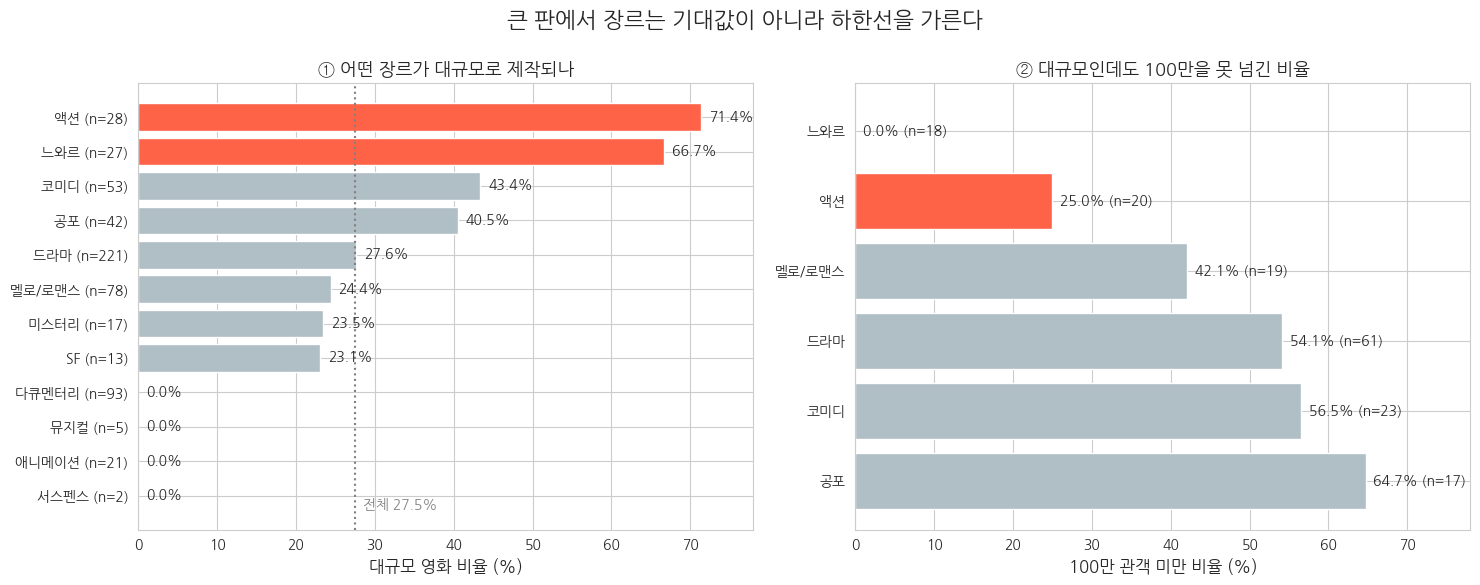

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

# ── 왼쪽: 장르별 대규모 비율 ──
ax = axes[0]
t = 장르규모.sort_values('비율', ascending=False)
라벨 = []
for 장르, 편수 in zip(t.index, t['편수']):
    라벨.append('%s (n=%d)' % (장르, 편수))

색 = []
for i in range(len(t)):
    색.append('tomato' if i < 2 else '#b0bec5')

막대 = ax.barh(라벨, t['비율'], color=색)
ax.invert_yaxis()
for 막, v in zip(막대, t['비율']):
    ax.text(v + 1, 막.get_y() + 막.get_height() / 2, '%.1f%%' % v, va='center', fontsize=10)

전체비율 = df['대규모'].mean() * 100
ax.axvline(전체비율, linestyle=':', color='gray')
ax.text(전체비율 + 1, len(t) - 0.6, '전체 %.1f%%' % 전체비율, fontsize=10, color='gray')
ax.set_xlim(0, 78)
ax.set_xlabel('대규모 영화 비율 (%)', fontsize=12)
ax.set_title('① 어떤 장르가 대규모로 제작되나', fontsize=13)

# ── 오른쪽: 대규모 안에서 100만 미만 비율 ──
ax = axes[1]
색2 = []
for i in range(len(하한)):
    색2.append('tomato' if i < 2 else '#b0bec5')

막대2 = ax.barh(하한.index, 하한['미만100만'], color=색2)
ax.invert_yaxis()
for 막, v, n in zip(막대2, 하한['미만100만'], 하한['편수']):
    ax.text(v + 1, 막.get_y() + 막.get_height() / 2,
            '%.1f%% (n=%d)' % (v, n), va='center', fontsize=10)
ax.set_xlim(0, 78)
ax.set_xlabel('100만 관객 미만 비율 (%)', fontsize=12)
ax.set_title('② 대규모인데도 100만을 못 넘긴 비율', fontsize=13)

fig.suptitle('큰 판에서 장르는 기대값이 아니라 하한선을 가른다', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

**해석**

공통 기준인 **스태프 251명 이상**으로 보면 대규모 영화는 165편(27.5%)이다.

장르별 대규모 비율은 액션 71.4%, 느와르 66.7%로 높고 다큐멘터리·애니메이션·뮤지컬은
0%다. 다만 **같은 0%라도 의미가 다르다.** 다큐멘터리는 93편 중 0편이라 확고한 사실이지만,
서스펜스는 2편 중 0편이라 아무 정보가 없다. 그래서 그래프에 편수를 함께 표시했다.

여기서 한 걸음 더 나아가, **대규모 영화만 놓고** 100만 관객 미만 비율을 보면
**느와르는 18편 전부가 100만을 넘겼고(0.0%)**, 공포는 64.7%가 100만 아래다.
액션은 25.0%로 낮은 편이다.

즉 큰 판에서 장르는 **얼마나 버느냐가 아니라 얼마나 안 망하느냐**를 가른다.
제작 규모가 크다고 모든 장르에서 비슷한 결과가 나오는 것은 아니다.

**기준에 휘둘리지 않는다.** 75퍼센타일인 264명으로 바꿔도 느와르 0.0%, 공포 64.3%로
순서와 결론이 그대로다.

**한계**: 장르별 대규모 편수가 17~61편으로 얇다. 특히 공포 17편, 느와르 18편에서
나온 비율이므로 참고치로 보아야 한다. 또 100만이라는 기준선은 관행적인 값이지
데이터에서 도출한 경계가 아니다.

---

# 5. 제작 규모별 관객수 분포 · 김민서

**가설**: 관객수 분포가 봉우리 두 개(쌍봉)로 나뉘는데, 그 원인이 제작 규모일 것이다.

관객수를 로그로 바꿔 분포를 그리면 봉우리가 두 개 나타난다. 무엇이 둘을 가르는지 확인한다.

> 이 분석은 처음에 **배급사 체급**으로 봉우리를 설명하려 했으나, 대형 배급사의 스태프
> 중앙값이 310명·중소가 42명으로 **배급사와 제작 규모가 분리되지 않았다.** 제작 규모만으로도
> 설명력이 더 높아(R² 0.562 vs 0.383) 규모 기준으로 바꿨다.

### 1단계. 전체 분포에 봉우리가 몇 개인가

관객수는 100명대부터 1,000만 명대까지 퍼져 있어 원본 그대로는 분포가 보이지 않는다.
**로그로 바꿔야** 모양이 드러난다. (`log1p`는 0이 들어와도 안전한 로그)

In [28]:
df['log1p관객수'] = np.log1p(df['box_off_num'])

print(df['box_off_num'].describe().round(0).to_string())
print()
print('평균 {:,.0f}명  /  중앙값 {:,.0f}명'.format(
    df['box_off_num'].mean(), df['box_off_num'].median()))

count         600.0
mean       708182.0
std       1828006.0
min             1.0
25%          1297.0
50%         12591.0
75%        479887.0
max      14262766.0

평균 708,182명  /  중앙값 12,591명


### 2단계. 제작 규모가 관객수를 얼마나 설명하는가

**R²**는 관객수의 흩어짐 중 몇 퍼센트를 규모가 설명하는지를 뜻한다. 1에 가까울수록 설명력이 크다.

In [29]:
그룹 = []
for 규모 in 규모목록:
    그룹.append(df[df['규모'] == 규모]['log1p관객수'].values)

전체 = np.concatenate(그룹)
집단간 = sum(len(a) * (a.mean() - 전체.mean()) ** 2 for a in 그룹)   # 규모가 만든 변동
전체변동 = ((전체 - 전체.mean()) ** 2).sum()
R2 = 집단간 / 전체변동

print('제작 규모의 관객수 설명력 R² = %.3f' % R2)
print()
print(df.groupby('규모', observed=True).agg(
    편수=('box_off_num', 'size'),
    관객중앙=('box_off_num', 'median')).to_string())

제작 규모의 관객수 설명력 R² = 0.562

             편수       관객중앙
규모                        
소(~80명)     297     1806.0
중(81~250명)  138    17752.5
대(251명~)    165  1169546.0


### 3단계. 배급사와 비교하면 어느 쪽이 더 잘 설명하나

처음 가설이었던 배급사 체급과 설명력을 나란히 놓는다.

In [30]:
def 정리(이름):
    이름 = str(이름).replace('(주)', '').replace('주식회사', '').strip()
    if '쇼박스' in 이름:
        return '쇼박스'
    if 'CJ' in 이름:
        return 'CJ엔터테인먼트'
    if '롯데' in 이름:
        return '롯데엔터테인먼트'
    if 'NEW' in 이름:
        return 'NEW'
    return 이름


df['배급사정리'] = df['distributor'].apply(정리)
대형목록 = ['CJ엔터테인먼트', '롯데엔터테인먼트', '쇼박스', 'NEW']
df['배급사체급'] = np.where(df['배급사정리'].isin(대형목록), '대형', '중소/독립')

print('[매칭 확인 — 반드시 눈으로 볼 것]')
print(df['배급사체급'].value_counts().to_string())
print()
print(df[df['배급사체급'] == '대형']['배급사정리'].value_counts().to_string())


def 설명력(열):
    그룹 = []
    for 값 in df[열].dropna().unique():
        그룹.append(df[df[열] == 값]['log1p관객수'].values)
    전체 = np.concatenate(그룹)
    집단간 = sum(len(a) * (a.mean() - 전체.mean()) ** 2 for a in 그룹)
    return 집단간 / ((전체 - 전체.mean()) ** 2).sum()


print()
print('제작 규모  R² = %.3f' % 설명력('규모'))
print('배급사체급 R² = %.3f' % 설명력('배급사체급'))
print()
print(df.groupby('배급사체급')['num_staff'].median().to_string())

[매칭 확인 — 반드시 눈으로 볼 것]
배급사체급
중소/독립    422
대형       178

배급사정리
CJ엔터테인먼트    60
롯데엔터테인먼트    52
NEW         38
쇼박스         28

제작 규모  R² = 0.562
배급사체급 R² = 0.413

배급사체급
대형       308.5
중소/독립     40.5


### 시각화

두 그룹의 편수가 다르면(소 297편 vs 대 165편) 막대 높이가 **편수 때문에** 달라 보인다.
`stat='density', common_norm=False`로 **각 그룹을 따로 100%로 맞춰** 모양만 비교한다.

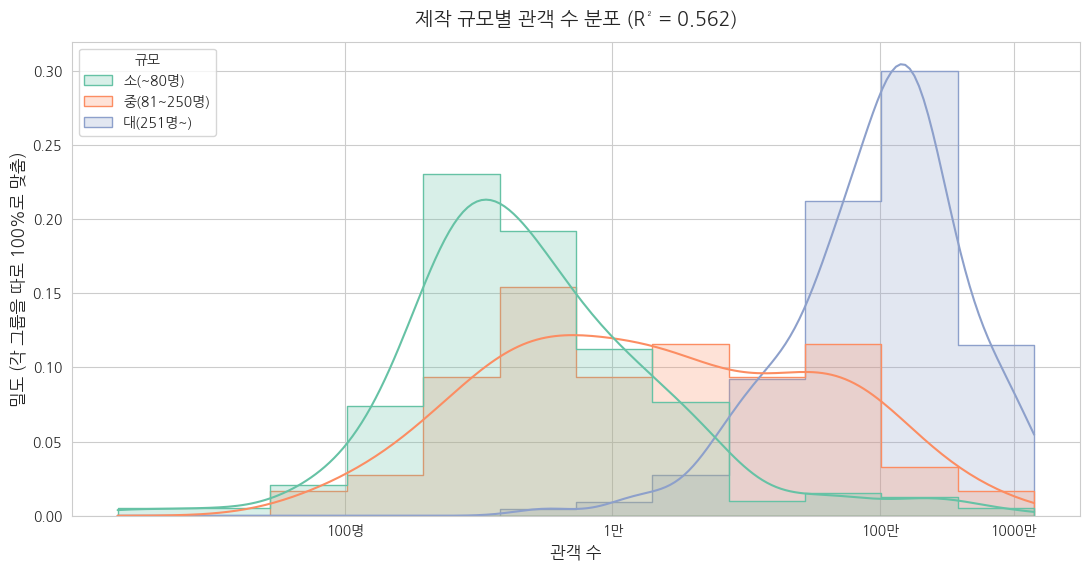

In [31]:
fig, ax = plt.subplots(figsize=(11, 5.8))

sns.histplot(data=df, x='log1p관객수', hue='규모', kde=True, element='step',
             stat='density', common_norm=False, palette='Set2', ax=ax)

# x축을 실제 관객수로 (로그값 0~16은 읽을 수 없으므로)
눈금 = [100, 10_000, 1_000_000, 10_000_000]
ax.set_xticks(np.log1p(눈금))
ax.set_xticklabels(['100명', '1만', '100만', '1000만'])

ax.set_xlabel('관객 수', fontsize=12)
ax.set_ylabel('밀도 (각 그룹을 따로 100%로 맞춤)', fontsize=12)
ax.set_title('제작 규모별 관객 수 분포 (R² = %.3f)' % R2, fontsize=14, pad=12)
plt.tight_layout()
plt.show()

**해석**

관객수는 평균 708,182명, 중앙값 12,591명으로 평균이 중앙값의 56배다. 소수의 대박 영화가
평균을 끌어올린 것이며, 로그로 바꿔 보면 **봉우리가 두 개**로 갈린다.

제작 규모별로 나누면 세 분포가 뚜렷이 다른 자리에 선다. 규모의 설명력은 **R² = 0.562**로,
관객수 흩어짐의 절반 이상을 규모가 설명한다.

처음 가설이었던 배급사 체급은 **R² = 0.383**으로 더 낮다. 게다가 대형 배급사의 스태프
중앙값이 310명, 중소가 42명이라 **배급사와 제작 규모는 분리되지 않는다.**
봉우리를 만든 것이 배급사 자체인지 그들이 다루는 작품의 규모인지는 이 분석으로 가릴 수 없다.

**한계**: 배급사 이름은 표기가 제각각이라(`CJ 엔터테인먼트`, `(주)쇼박스`) 정리 규칙에 따라
분류가 달라진다. 그래서 매칭 결과를 코드에서 직접 출력해 확인했다. `CJ E&M 영화부문`처럼
계열사로 볼 수도 있는 이름은 대형에 포함하지 않았다.

---

# 6. 인력과 관객 사이에 문턱이 있는가 · 이승주

**가설**: "큰 영화가 스태프 1명당 관객수(효율)도 24배 높다"는 말이 사실이라면,
제작 규모가 커질수록 효율이 꾸준히 올라야 한다.

효율은 `관객수 ÷ 스태프수`로 정의한다. 다만 **분모가 작으면 값이 자동으로 커지므로**
지표 자체를 의심하면서 확인한다.

### 1단계. 24배가 사실인가 — 규모별 효율

In [32]:
d = df[df['num_staff'] > 0].copy()      # 스태프 0명이면 나눌 수 없음
d['효율'] = d['box_off_num'] / d['num_staff']
print('스태프 0명이라 제외한 영화: %d편' % (len(df) - len(d)))
print()

print(d.groupby('규모', observed=True).agg(
    편수=('효율', 'size'),
    스태프중앙=('num_staff', 'median'),
    관객중앙=('box_off_num', 'median'),
    효율중앙=('효율', 'median')).round(0).to_string())

소 = d[d['규모'] == '소(~80명)']
대 = d[d['규모'] == '대(251명~)']
print()
print('효율 %.1f배' % (대['효율'].median() / 소['효율'].median()))

스태프 0명이라 제외한 영화: 32편

             편수  스태프중앙       관객중앙    효율중앙
규모                                       
소(~80명)     265   19.0     1958.0   131.0
중(81~250명)  138  136.0    17752.0   129.0
대(251명~)    165  356.0  1169546.0  3144.0

효율 24.0배


### 2단계. 그 24배는 어디서 왔나 — 분모와 분자로 쪼개기

In [33]:
스태프배수 = 대['num_staff'].median() / 소['num_staff'].median()
관객배수 = 대['box_off_num'].median() / 소['box_off_num'].median()
print('스태프 %.1f배  →  관객 %.1f배' % (스태프배수, 관객배수))

스태프 18.7배  →  관객 597.3배


### 3단계. 단조 증가인가 U자인가

소·중·대 3칸으로는 안이 뭉개지므로 10등분해서 모양을 본다.
`qcut`은 **편수가 같도록** 10등분한다(`cut`은 값 범위를 10등분).

In [34]:
d['분위'] = pd.qcut(d['num_staff'], 10, labels=False) + 1

분위표 = d.groupby('분위').agg(
    편수=('효율', 'size'),
    스태프중앙=('num_staff', 'median'),
    관객중앙=('box_off_num', 'median'),
    효율중앙=('효율', 'median')).round(0)
print(분위표.to_string())

바닥 = 분위표['효율중앙'].idxmin()
print()
print('효율 최저: %d분위 (스태프 %.0f명, 1명당 %.0f명)'
      % (바닥, 분위표.loc[바닥, '스태프중앙'], 분위표.loc[바닥, '효율중앙']))

    편수  스태프중앙       관객중앙    효율중앙
분위                              
1   64    3.0     2148.0   870.0
2   60   12.0     1609.0   140.0
3   47   23.0     1958.0    84.0
4   58   44.0     1718.0    37.0
5   55   74.0     3916.0    48.0
6   57  117.0     7721.0    58.0
7   56  192.0    51440.0   243.0
8   57  279.0   616481.0  2099.0
9   57  351.0  1046313.0  3247.0
10  57  471.0  1717566.0  3375.0

효율 최저: 4분위 (스태프 44명, 1명당 37명)


### 4단계. 분모 함정인가 — 효율 상위가 어떤 영화들인가

In [35]:
print('[효율 상위 5편]')
print(d.nlargest(5, '효율')[['title', 'genre', 'num_staff',
                            'box_off_num', '효율']].round(0).to_string(index=False))
print()
print('[대규모인데 효율 하위 3편]')
print(대.nsmallest(3, '효율')[['title', 'genre', 'num_staff',
                             'box_off_num', '효율']].round(0).to_string(index=False))

[효율 상위 5편]
             title genre  num_staff  box_off_num        효율
   님아, 그 강을 건너지 마오 다큐멘터리          3      4802169 1600723.0
           울지마, 톤즈 다큐멘터리          1       444327  444327.0
뽀로로 극장판 컴퓨터 왕국 대모험 애니메이션          2       446054  223027.0
               스파이   코미디         14      2318748  165625.0
              설국열차    SF         67      9350351  139557.0

[대규모인데 효율 하위 3편]
   title genre  num_staff  box_off_num   효율
     무명인  미스터리        262         3199 12.0
       귀    공포        255        13108 51.0
사요나라 이츠카   드라마        404        23229 57.0


### 5단계. 장르·연도 때문은 아닌가 — 교란변수 통제

문턱이 특정 장르나 특정 연도에서만 나타나는 것은 아닌지 확인한다.

In [36]:
def 문턱확인(데이터, 라벨, n):
    데이터 = 데이터.copy()
    데이터['분위'] = pd.qcut(데이터['num_staff'], n, labels=False, duplicates='drop') + 1
    t = 데이터.groupby('분위').agg(편수=('title', 'size'),
                               스태프=('num_staff', 'median'),
                               관객=('box_off_num', 'median'))
    t['배수'] = (t['관객'] / t['관객'].shift(1)).round(2)
    print('[%s]  %d편' % (라벨, len(데이터)))
    print(t.to_string())
    print()


문턱확인(d, '전체', 10)
문턱확인(d[d['genre'] == '드라마'], '드라마만 — 장르 고정', 5)
문턱확인(d[d['연도'] <= 2012], '2010~2012년만 — 연도 고정', 10)

[전체]  568편
    편수    스태프         관객     배수
분위                             
1   64    3.0     2148.5    NaN
2   60   12.0     1609.0   0.75
3   47   23.0     1958.0   1.22
4   58   43.5     1718.5   0.88
5   55   74.0     3916.0   2.28
6   57  117.0     7721.0   1.97
7   56  192.5    51440.0   6.66
8   57  279.0   616481.0  11.98
9   57  351.0  1046313.0   1.70
10  57  471.0  1717566.0   1.64

[드라마만 — 장르 고정]  217편
    편수    스태프        관객     배수
분위                            
1   46   14.0    1639.0    NaN
2   41   55.0    1081.0   0.66
3   43  103.0    3523.0   3.26
4   44  232.5  127319.0  36.14
5   43  410.0  956103.0   7.51

[2010~2012년만 — 연도 고정]  245편
    편수    스태프         관객    배수
분위                            
1   28    3.0     1193.5   NaN
2   25   14.0     1356.0  1.14
3   21   24.0     2821.0  2.08
4   24   56.0     1026.0  0.36
5   25   86.0     6034.0  5.88
6   24  124.5    18766.0  3.11
7   24  217.5   185506.0  9.89
8   26  291.0   999298.5  5.39
9   23  354.0   953682.0  0

### 6단계. 배급사와는 분리되는가

스태프 수가 커질수록 대형 배급사 비율도 같이 오른다면, 둘을 분리할 수 없다.

In [37]:
print(d.groupby('분위').agg(
    편수=('title', 'size'),
    대형배급비율=('배급사체급', lambda s: round((s == '대형').mean() * 100, 1))).to_string())

    편수  대형배급비율
분위            
1   64     6.2
2   60     8.3
3   47     2.1
4   58     5.2
5   55    20.0
6   57    21.1
7   56    35.7
8   57    57.9
9   57    71.9
10  57    82.5


### 시각화

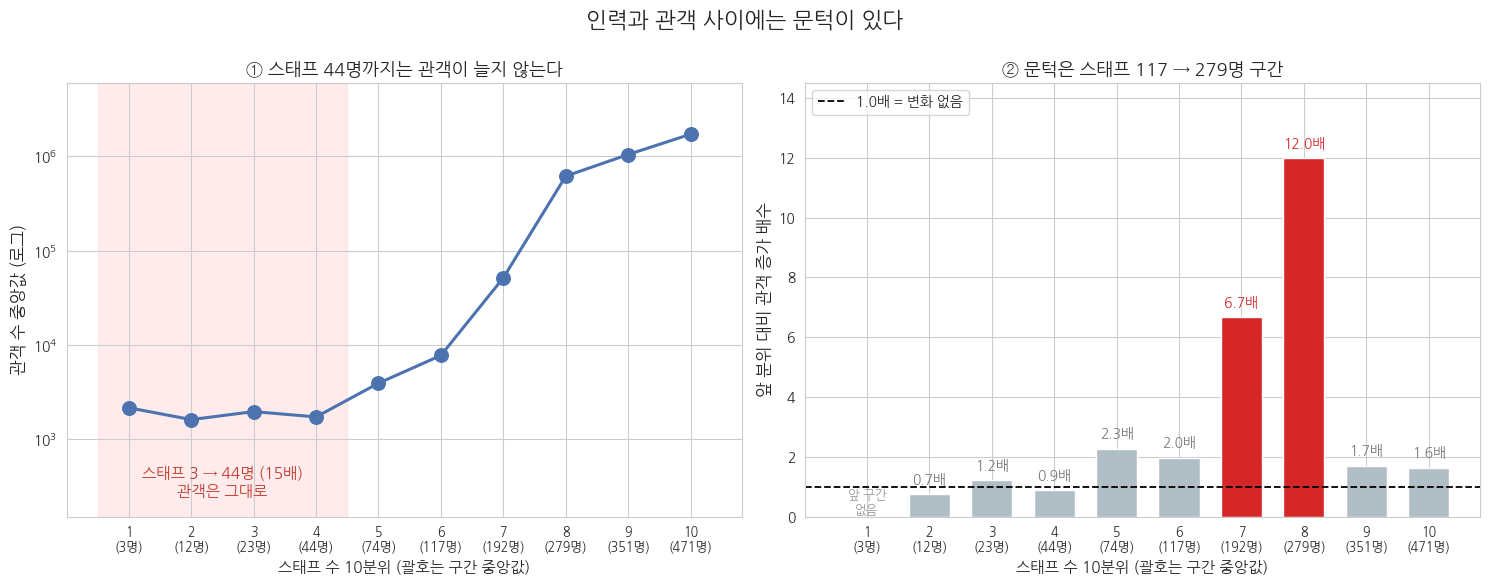

In [38]:
t = d.groupby('분위').agg(스태프중앙=('num_staff', 'median'),
                        관객중앙=('box_off_num', 'median'))
t['배수'] = t['관객중앙'] / t['관객중앙'].shift(1)   # 앞 분위 대비

라벨 = []
for 분위, 스태프 in zip(t.index, t['스태프중앙']):
    라벨.append('%d\n(%.0f명)' % (분위, 스태프))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), sharex=True)

# ── 왼쪽: 관객수 곡선 ──
ax = axes[0]
ax.axvspan(0.5, 4.5, color='#ffd9d9', alpha=0.5, zorder=0)   # 평평한 구간 배경
ax.plot(t.index, t['관객중앙'], color='#4c72b0', linewidth=2.2, zorder=2)
ax.scatter(t.index, t['관객중앙'], s=95, color='#4c72b0', zorder=3)
ax.set_yscale('log')
ax.text(2.5, 250, '스태프 3 → 44명 (15배)\n관객은 그대로',
        fontsize=11, fontweight='bold', color='#c0392b', ha='center')
ax.set_ylim(150, 6e6)
ax.set_ylabel('관객 수 중앙값 (로그)', fontsize=12)
ax.set_title('① 스태프 44명까지는 관객이 늘지 않는다', fontsize=13)

# ── 오른쪽: 앞 분위 대비 증가 배수 ──
ax = axes[1]
유효 = t.dropna(subset=['배수'])        # 1분위는 앞 구간이 없어 계산 불가

색 = []
for v in 유효['배수']:
    색.append('#d62728' if v >= 5 else '#b0bec5')

ax.bar(유효.index, 유효['배수'], color=색, width=0.66)
ax.axhline(1, color='black', linestyle='--', linewidth=1.3, label='1.0배 = 변화 없음')
ax.text(1, 0.45, '앞 구간\n없음', ha='center', va='center', fontsize=9, color='#999')

for 분위, v in zip(유효.index, 유효['배수']):
    ax.text(분위, v + 0.35, '%.1f배' % v, ha='center', fontsize=10,
            fontweight='bold' if v >= 5 else 'normal',
            color='#d62728' if v >= 5 else '#777')

ax.set_ylim(0, 14.5)
ax.set_ylabel('앞 분위 대비 관객 증가 배수', fontsize=12)
ax.set_title('② 문턱은 스태프 117 → 279명 구간', fontsize=13)
ax.legend(loc='upper left', fontsize=10)

for ax in axes:
    ax.set_xticks(t.index)
    ax.set_xticklabels(라벨, fontsize=9)
    ax.set_xlabel('스태프 수 10분위 (괄호는 구간 중앙값)', fontsize=11)

fig.suptitle('인력과 관객 사이에는 문턱이 있다', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

**해석**

스태프가 3명에서 44명으로 **15배 늘어도 관객은 그대로**다(2,148 → 1,718명).
로그 축인데도 선이 수평이다.

증가 배수로 보면 2~4분위는 0.7 / 1.2 / 0.9배로 1 근처에 머물다가, 7분위 6.7배,
8분위 **12.0배**로 두 칸만 솟고 다시 1.6~1.7배로 내려앉는다. 증가가
**스태프 117~279명 한 구간에 몰려 있다.**

인력을 조금씩 늘려 관객이 조금씩 느는 구조가 아니라 **문턱이 있는 구조**다.
효율이 단조 증가가 아니라 U자인 것도 여기서 나온다 — 문턱 아래에서는 분모만 커지고
분자는 그대로라 효율이 떨어지고, 문턱을 넘으면 분자가 크게 늘어 효율이 올라간다.

**교란을 통제해도 남는다.** 드라마만 보면 스태프 103 → 232명 구간에서 36.1배,
2010~2012년만 보면 86~291명 구간에서 5.9~9.9배로 같은 자리에 문턱이 나타난다.

**한계 1 — 지표의 함정**: "큰 영화가 24배 효율적"은 맞지만 오해를 낳는다. 효율 상위 5편 중
3편이 스태프 1~3명(님아 3명, 울지마 톤즈 1명, 뽀로로 2명)이다. 분모가 작으면 값이 자동으로 커진다.

**한계 2 — 배급사와 분리되지 않는다**: 대형 배급사 비율이 1분위 6%에서 10분위 81%로
같이 올라간다. 문턱이 스태프 수 때문인지 배급 체급 때문인지 이 데이터로는 가릴 수 없다.

**한계 3 — 인과가 아니다**: 인력을 늘려서 관객이 는 것이 아니라, **흥행이 예상되는 작품에
인력이 투입된 것**일 수 있다.

---

# 7. 수치형 변수와 관객수의 관계 · 김민서

**가설**: 수치형 변수 중 관객수와 가장 관련이 깊은 것은 제작 규모(스태프 수)일 것이다.

상관계수는 **직선 관계의 세기**만 재는 값이다. 순서나 인과는 말해주지 않는다는 점을
전제로 본다.

### 1단계. 전체 상관 한눈에 보기

In [39]:
df['log전작관객'] = np.log1p(df['dir_prev_bfnum'])

이름 = {'time': '상영시간', 'num_staff': '스태프 수', 'num_actor': '배우 수',
       'log전작관객': '전작 관객수(로그)', 'log1p관객수': '관객수(로그)'}
열 = list(이름.keys())

상관 = df[열].corr().rename(index=이름, columns=이름)
상관.round(2)

,상영시간,스태프 수,배우 수,전작 관객수(로그),관객수(로그)
상영시간,1.00,0.62,0.11,0.34,0.60
스태프 수,0.62,1.00,0.08,0.47,0.75
배우 수,0.11,0.08,1.00,0.01,0.11
전작 관객수(로그),0.34,0.47,0.01,1.00,0.45
관객수(로그),0.60,0.75,0.11,0.45,1.00


### 2단계. 상영시간의 상관은 진짜인가 — 편상관

상영시간과 스태프 수의 상관이 0.623으로 높다. 그렇다면 상영시간이 관객수와 보이는 상관도
**스태프 수의 그림자**일 수 있다. 한 변수를 고정하고 다시 계산해 본다.

In [40]:
def 편상관(x, y, 고정):
    """고정 변수의 영향을 뺀 뒤 x와 y의 상관을 구한다."""
    rxy = df[[x, y]].corr().iloc[0, 1]
    rxz = df[[x, 고정]].corr().iloc[0, 1]
    ryz = df[[y, 고정]].corr().iloc[0, 1]
    return (rxy - rxz * ryz) / np.sqrt((1 - rxz ** 2) * (1 - ryz ** 2))


print('상영시간 × 관객수   단순 %.3f  →  스태프 고정 후 %.3f'
      % (df[['time', 'log1p관객수']].corr().iloc[0, 1],
         편상관('time', 'log1p관객수', 'num_staff')))
print('스태프  × 관객수   단순 %.3f  →  상영시간 고정 후 %.3f'
      % (df[['num_staff', 'log1p관객수']].corr().iloc[0, 1],
         편상관('num_staff', 'log1p관객수', 'time')))

상영시간 × 관객수   단순 0.598  →  스태프 고정 후 0.256
스태프  × 관객수   단순 0.745  →  상영시간 고정 후 0.594


### 3단계. 전작 관객수의 상관은 무엇을 재고 있나

`dir_prev_bfnum`을 0으로 채웠기 때문에 **신인 330편이 전부 x=0에 몰려 있다.**
그 330편은 관객수도 낮아서, 상관계수가 "전작 성적의 예측력"이 아니라
**"신인이냐 아니냐"**를 일부 재고 있을 수 있다.

In [41]:
전작있음 = df[df['dir_prev_num'] > 0]

print('600편 전체 (0으로 채운 330편 포함) r = %.3f'
      % df[['log전작관객', 'log1p관객수']].corr().iloc[0, 1])
print('전작이 있는 %d편만              r = %.3f'
      % (len(전작있음),
         np.corrcoef(np.log1p(전작있음['dir_prev_bfnum']),
                     np.log1p(전작있음['box_off_num']))[0, 1]))

600편 전체 (0으로 채운 330편 포함) r = 0.448
전작이 있는 270편만              r = 0.409


### 4단계. 변환에 휘둘리지 않는가 — 스피어만

피어슨 상관은 로그를 씌우느냐에 따라 값이 달라진다.
**순위만 보는 스피어만**으로도 순서가 유지되는지 확인한다.

In [42]:
비교 = pd.DataFrame({
    '피어슨': df[열].corr()['log1p관객수'],
    '스피어만': df[열].corr(method='spearman')['log1p관객수']}).round(3)
비교.index = [이름[i] for i in 비교.index]
비교

,피어슨,스피어만
상영시간,0.598,0.609
스태프 수,0.745,0.695
배우 수,0.111,0.127
전작 관객수(로그),0.448,0.448
관객수(로그),1.000,1.000


### 시각화

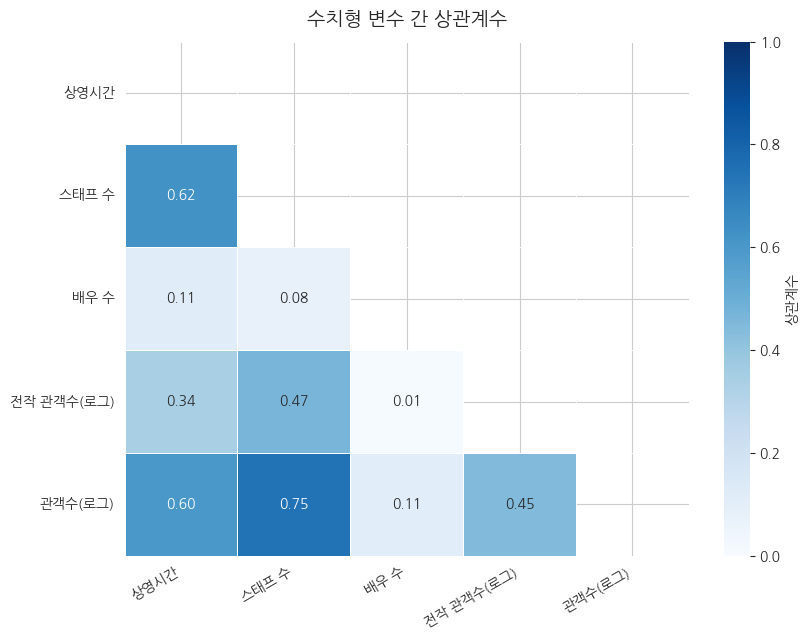

In [43]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))

# 위쪽 삼각형과 대각선을 가려 볼 값만 남긴다
가림 = np.triu(np.ones_like(상관, dtype=bool))

sns.heatmap(상관, mask=가림, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': '상관계수'})
ax.set_title('수치형 변수 간 상관계수', fontsize=14, pad=12)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**해석**

관객수(로그)와 가장 상관이 높은 변수는 **스태프 수(0.745)**다. 상영시간 0.598,
전작 관객수 0.448이 뒤를 잇고, **배우 수는 0.111로 거의 무관**하다.

배우 수가 무관한 것은 이 변수가 **주연 배우의 "명수"일 뿐 유명세가 아니기 때문**으로 보인다.
3명이 나오든 5명이 나오든 그 자체로는 흥행과 관계가 없다.

**상영시간의 0.598은 대부분 스태프 수의 그림자다.** 스태프 수를 고정하면 0.256으로
절반 이하가 된다. 반대로 스태프 수는 상영시간을 고정해도 0.594로 버틴다.
긴 영화가 흥행하는 것이 아니라 **큰 영화가 길고, 큰 영화가 흥행하는 것**이다.

**전작 관객수 0.448도 조심해야 한다.** 결측을 0으로 채운 신인 330편이 전부 x=0에 몰려
상관을 끌어올렸다. **전작이 있는 270편만 보면 0.409**다. 9번에서는 이 270편 기준
(0.406, 로그10)으로 계산한다.

스피어만으로 봐도 순서는 같다. 변환 방식 때문에 생긴 결과는 아니다.

**한계**: 상관계수는 **방향을 말해주지 않는다.** 스태프가 많아서 흥행한 것인지, 흥행이
예상돼서 스태프를 투입한 것인지 구분할 수 없다. 또 직선 관계만 재기 때문에,
6번에서 본 **문턱 구조**처럼 휘어진 관계는 상관계수 하나로 담기지 않는다.

---

# 8. 제작 규모에 따라 장르 영향력이 달라지는가 · 이승주

**가설**: 제작 규모를 고정하면, 장르가 관객수를 가르는 정도가 규모마다 다를 것이다.

주의할 점이 있다. **규모마다 장르 구성 자체가 다르다.** 대규모에는 다큐멘터리와
애니메이션이 한 편도 없다. 구성을 맞추지 않으면 "장르 효과"가 아니라 "구성 차이"를 재게 된다.

### 0단계. 지표 계산 함수

1차와 교정을 **같은 잣대로** 비교해야 하므로 계산을 함수로 묶는다.

- **최고최저배수**: 장르별 관객수 중앙값의 최대 ÷ 최소
- **p값**: 장르 간 차이가 우연인지 (`f_oneway` = 분산분석)
- **장르간편차**: 장르별 로그 관객수 중앙값들의 표준편차

In [44]:
장르20 = df['genre'].value_counts()
장르20 = 장르20[장르20 >= 20].index.tolist()   # 20편 이상인 장르만
sub = df[df['genre'].isin(장르20)].copy()


def 장르효과(데이터):
    """규모별로 '장르가 관객수를 얼마나 가르는가'를 계산한다."""
    행들 = []
    for 규모 in 규모목록:
        g = 데이터[데이터['규모'] == 규모]

        편수 = g['genre'].value_counts()
        쓸장르 = 편수[편수 >= 5].index.tolist()   # 이 규모에서 5편 이상인 장르만
        g = g[g['genre'].isin(쓸장르)]

        중앙값 = g.groupby('genre')['box_off_num'].median()
        로그중앙 = g.groupby('genre')['log관객수'].median()

        그룹 = []
        for 장르 in 쓸장르:
            그룹.append(g[g['genre'] == 장르]['log관객수'])
        p값 = stats.f_oneway(*그룹)[1]      # *를 붙이면 리스트를 하나씩 풀어서 전달

        행들.append({'규모': 규모,
                    '편수': len(g),
                    '장르수': len(쓸장르),
                    '최고최저배수': round(중앙값.max() / 중앙값.min(), 1),
                    'p값': round(p값, 4),
                    '장르간편차': round(로그중앙.std(), 3)})

    return pd.DataFrame(행들).set_index('규모')

### 1단계. 규모마다 장르 구성이 같은가 — 먼저 확인할 것

In [45]:
구성 = pd.crosstab(sub['규모'], sub['genre'])
구성

genre,공포,느와르,다큐멘터리,드라마,멜로/로맨스,애니메이션,액션,코미디
규모,,,,,,,,
소(~80명),12,3,90,94,41,16,3,18
중(81~250명),13,6,3,66,18,5,5,12
대(251명~),17,18,0,61,19,0,20,23


### 2단계. [1차] 주요 장르 전체로 계산 — 교란이 섞인 결과

In [46]:
일차 = 장르효과(sub)
일차

,편수,장르수,최고최저배수,p값,장르간편차
규모,,,,,
소(~80명),271,6,45.0,0.0000,0.571
중(81~250명),125,7,47.3,0.0679,0.636
대(251명~),158,6,3.6,0.0028,0.213


### 3단계. [교정] 세 규모 모두에 5편 이상 있는 공통 장르만

In [47]:
공통장르 = []
for 장르 in 구성.columns:
    if (구성[장르] >= 5).all():        # 세 규모 모두에서 5편 이상이면
        공통장르.append(장르)

print('공통 장르:', 공통장르)
print()

공통 = sub[sub['genre'].isin(공통장르)].copy()
이차 = 장르효과(공통)
print(이차.to_string())

공통 장르: ['공포', '드라마', '멜로/로맨스', '코미디']

             편수  장르수  최고최저배수      p값  장르간편차
규모                                         
소(~80명)     165    4     3.1  0.0095  0.206
중(81~250명)  109    4    47.3  0.0156  0.747
대(251명~)    120    4     2.8  0.2966  0.188


### 4단계. 1차 vs 교정 — 결론이 바뀌는가

In [48]:
비교표 = pd.DataFrame({'1차_배수': 일차['최고최저배수'],
                    '교정_배수': 이차['최고최저배수'],
                    '1차_p': 일차['p값'],
                    '교정_p': 이차['p값']})
비교표

,1차_배수,교정_배수,1차_p,교정_p
규모,,,,
소(~80명),45.0,3.1,0.0000,0.0095
중(81~250명),47.3,47.3,0.0679,0.0156
대(251명~),3.6,2.8,0.0028,0.2966


### 5단계. 시각화에 쓸 표 — 공통 장르의 규모별 중앙값

In [49]:
표 = 공통.pivot_table(index='규모', columns='genre',
                     values='box_off_num', aggfunc='median', observed=True)
print(표.round(0).to_string())
print()
print('[중규모의 장르별 편수]')
print(공통[공통['규모'] == '중(81~250명)']['genre'].value_counts().to_string())

genre             공포       드라마     멜로/로맨스       코미디
규모                                                 
소(~80명)       1474.0    1224.0      660.0    2038.0
중(81~250명)  251551.0    5320.0    18874.0  100408.0
대(251명~)    616481.0  814570.0  1715370.0  953682.0

[중규모의 장르별 편수]
genre
드라마       66
멜로/로맨스    18
공포        13
코미디       12


### 시각화 ① — 교정으로 무엇이 바뀌었나

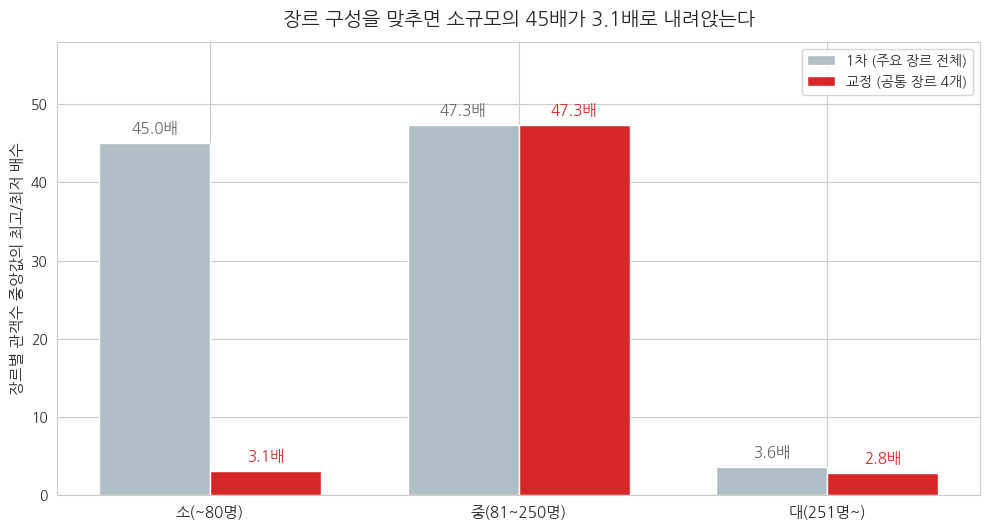

In [50]:
일차배수 = 일차['최고최저배수'].tolist()   # 표에서 숫자만 꺼내 리스트로
이차배수 = 이차['최고최저배수'].tolist()

x = np.arange(3)
w = 0.36

fig, ax = plt.subplots(figsize=(10, 5.4))
ax.bar(x - w / 2, 일차배수, w, label='1차 (주요 장르 전체)', color='#b0bec5')
ax.bar(x + w / 2, 이차배수, w, label='교정 (공통 장르 4개)', color='#d62728')

for i in range(3):
    ax.text(i - w / 2, 일차배수[i] + 1.3, '%.1f배' % 일차배수[i],
            ha='center', fontsize=11, color='#666')
    ax.text(i + w / 2, 이차배수[i] + 1.3, '%.1f배' % 이차배수[i],
            ha='center', fontsize=11, fontweight='bold', color='#d62728')

ax.set_xticks(x)
ax.set_xticklabels(규모목록, fontsize=11)
ax.set_ylim(0, 58)
ax.set_ylabel('장르별 관객수 중앙값의 최고/최저 배수', fontsize=11)
ax.set_title('장르 구성을 맞추면 소규모의 45배가 3.1배로 내려앉는다', fontsize=14, pad=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 시각화 ② — 규모별 장르 격차

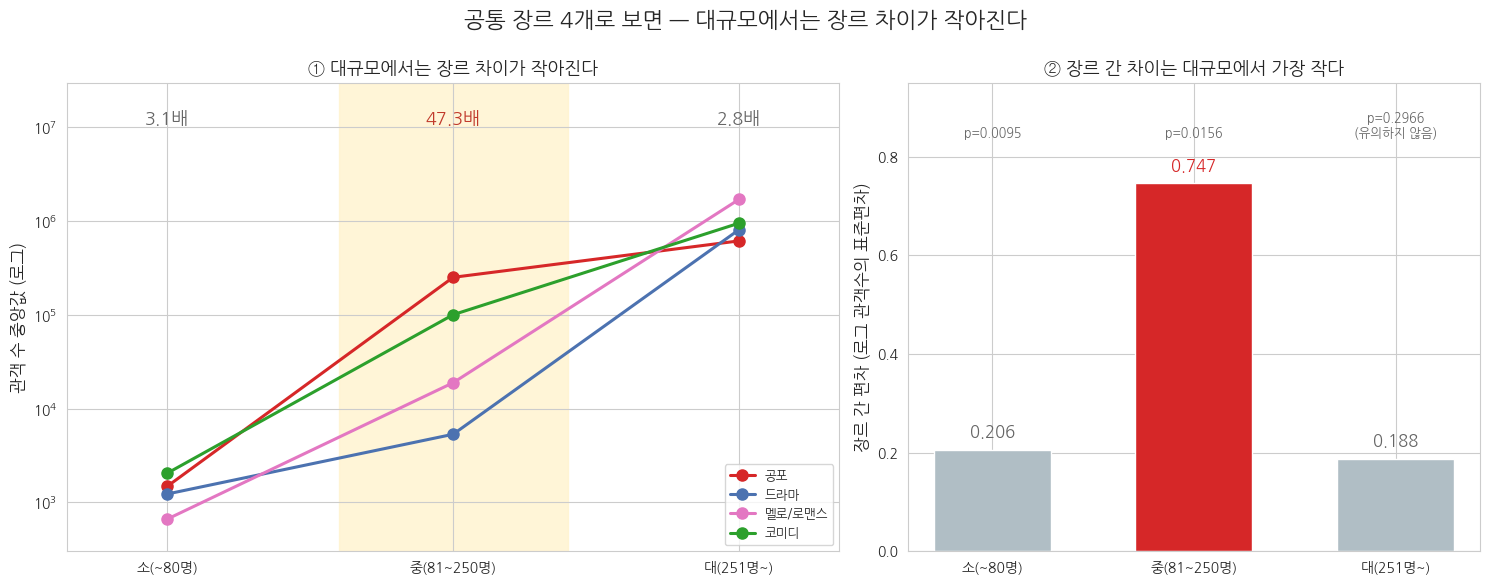

In [51]:
간편차 = 이차['장르간편차'].tolist()
배수 = 이차['최고최저배수'].tolist()
p값들 = 이차['p값'].tolist()
x = np.arange(3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8),
                         gridspec_kw={'width_ratios': [1.35, 1]})

# ── 왼쪽: 장르별 선 ──
ax = axes[0]
ax.axvspan(0.6, 1.4, color='#fff3cd', alpha=0.8, zorder=0)   # 중규모 강조

색 = {'공포': '#d62728', '드라마': '#4c72b0',
     '멜로/로맨스': '#e377c2', '코미디': '#2ca02c'}
for 장르 in 공통장르:
    ax.plot(x, 표[장르].values, marker='o', markersize=8,
            linewidth=2.2, label=장르, color=색[장르], zorder=2)

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(규모목록, fontsize=10)
ax.set_xlim(-0.35, 2.35)
ax.set_ylim(300, 3e7)
ax.set_ylabel('관객 수 중앙값 (로그)', fontsize=12)
ax.set_title('① 대규모에서는 장르 차이가 작아진다', fontsize=13)
ax.legend(fontsize=9, loc='lower right')

for i in range(3):
    ax.text(i, 1.1e7, '%.1f배' % 배수[i], ha='center', fontsize=13,
            fontweight='bold', color='#c0392b' if i == 1 else '#666')

# ── 오른쪽: 장르 간 편차 ──
ax = axes[1]
ax.bar(x, 간편차, color=['#b0bec5', '#d62728', '#b0bec5'], width=0.58)

for i in range(3):
    ax.text(i, 간편차[i] + 0.025, '%.3f' % 간편차[i], ha='center', fontsize=12,
            fontweight='bold', color='#d62728' if i == 1 else '#666')
    꼬리 = '\n(유의하지 않음)' if p값들[i] >= 0.05 else ''
    ax.text(i, 0.84, 'p=%.4f%s' % (p값들[i], 꼬리),
            ha='center', fontsize=9, color='#666')

ax.set_xticks(x)
ax.set_xticklabels(규모목록, fontsize=10)
ax.set_ylim(0, 0.95)
ax.set_ylabel('장르 간 편차 (로그 관객수의 표준편차)', fontsize=12)
ax.set_title('② 장르 간 차이는 대규모에서 가장 작다', fontsize=13)

fig.suptitle('공통 장르 4개로 보면 — 대규모에서는 장르 차이가 작아진다',
             fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

**해석**

세 규모 모두에 5편 이상 있는 **공통 장르 4개**(공포·드라마·멜로/로맨스·코미디)로 맞추면,
장르에 따른 관객수 격차는 소규모 **3.1배**, 중규모 **47.3배**, 대규모 **2.8배**다.

제한 없이 봤을 때 소규모가 45배로 나온 것은 **소규모에만 있는 다큐멘터리(90편)·
애니메이션(16편)** 때문이었다. 대규모에는 두 장르가 0편이라 애초에 비교가 성립하지 않는다.
교정하니 45 → 3.1배로 내려앉았고, **중규모만 47.3배 그대로**였다. 교정이 중규모를 봐준 것이
아니라 나머지 둘이 착시였다.

왼쪽 그림에서 네 장르 선은 소규모에서 붙어 있다가 중규모에서 벌어지고 대규모에서 다시 모인다.
대규모에서는 순서까지 뒤집힌다 — 중규모 1등이던 공포가 꼴찌(61만)가 되고, 꼴찌였던 드라마가
81만으로 올라선다.

**장르 차이가 유의하지 않은 것은 대규모뿐이다(p=0.2966).** 소규모(3.1배, p=0.0095)와
중규모(47.3배, p=0.0156)에서는 장르 간 차이가 남는다.

**결론: 장르 선택의 영향은 대규모에서 가장 작다.**

> 4번과 이어 보면 이렇게 정리된다. 대규모에서 장르는 **중앙값(얼마나 버느냐)은 못 가르지만
> 하한선(얼마나 안 망하느냐)은 가른다.** 느와르 대작 18편은 전부 100만을 넘겼고
> 공포 대작은 64.7%가 100만 아래다.

**한계**: 중규모의 공포는 13편, 코미디는 12편으로 표본이 얇아 47.3배는 참고치로 보아야 한다.
또 장르는 영화당 하나만 기록되어 있어 여러 장르에 걸친 영화는 반영되지 않는다.

---

# 9. 감독 경력은 흥행을 만드는가 · 김희경

**가설**: 감독의 경력이 흥행에 영향을 줄 것이다.

단순 비교 → 교란변수 통제 → 전작 성적의 예측력 → **변수 자체의 신뢰성**까지 파고든다.

### 0단계. 변수 구조부터 확인

결측을 채우기 전에 **그 결측이 무엇인지**부터 본다.

In [52]:
원본 = pd.read_csv(url)
print('dir_prev_bfnum 결측      : %d개' % 원본['dir_prev_bfnum'].isna().sum())
print('dir_prev_num == 0인 행   : %d개' % (원본['dir_prev_num'] == 0).sum())
print('두 조건이 완전히 일치하는가:',
      (원본['dir_prev_bfnum'].isna() == (원본['dir_prev_num'] == 0)).all())
print()
print(df['감독'].value_counts().to_string())

dir_prev_bfnum 결측      : 330개
dir_prev_num == 0인 행   : 330개
두 조건이 완전히 일치하는가: True

감독
신인    330
경력    270


### 1단계. 단순 비교

In [53]:
단순 = df.groupby('감독').agg(편수=('title', 'size'),
                           관객중앙=('box_off_num', 'median'),
                           스태프중앙=('num_staff', 'median')).loc[['신인', '경력']]
print(단순.to_string())
print()
print('관객수 %.1f배  /  스태프 %.1f배'
      % (단순.loc['경력', '관객중앙'] / 단순.loc['신인', '관객중앙'],
         단순.loc['경력', '스태프중앙'] / 단순.loc['신인', '스태프중앙']))

     편수      관객중앙  스태프중앙
감독                      
신인  330    3401.5   37.5
경력  270  222258.0  215.5

관객수 65.3배  /  스태프 5.7배


### 2단계. 제작 규모 고정 — 교란변수 통제

관객수도 65배 차이지만 **스태프 수도 5.7배** 차이 난다.
차이의 원인이 경력인지 규모인지 구분해야 한다.

In [54]:
print('[신인·경력의 제작 규모 배정 비율 (%)]')
print((pd.crosstab(df['감독'], df['규모'], normalize='index') * 100).round(1).to_string())
print()

print('[규모를 고정하고 다시 비교]')
for 규모 in 규모목록:
    a = df[(df['규모'] == 규모) & (df['감독'] == '경력')]['box_off_num']
    b = df[(df['규모'] == 규모) & (df['감독'] == '신인')]['box_off_num']
    print('  %-12s 경력 %3d편 %9.0f  /  신인 %3d편 %8.0f  = %5.2f배'
          % (규모, len(a), a.median(), len(b), b.median(), a.median() / b.median()))

[신인·경력의 제작 규모 배정 비율 (%)]
규모  소(~80명)  중(81~250명)  대(251명~)
감독                               
경력     28.9        24.8      46.3
신인     66.4        21.5      12.1

[규모를 고정하고 다시 비교]
  소(~80명)      경력  78편      1878  /  신인 219편     1806  =  1.04배
  중(81~250명)   경력  67편     35567  /  신인  71편     9323  =  3.81배
  대(251명~)     경력 125편   1310895  /  신인  40편   885336  =  1.48배


### 3단계. 전작 성적이 다음 흥행으로 이어지는가

전작이 있는 270편만 본다. 관객수 분포가 크게 치우쳐 있어 **두 값 모두 로그**로 바꿔 계산한다.

In [55]:
경력df = df[df['dir_prev_num'] > 0].copy()
경력df['log전작'] = np.log10(경력df['dir_prev_bfnum'])

상관 = 경력df[['log전작', 'log관객수']].corr().iloc[0, 1]
print('전작 있는 %d편 (감독 %d명)' % (len(경력df), 경력df['director'].nunique()))
print('전작 관객수 × 이번 관객수 상관(로그-로그) = %.3f' % 상관)

전작 있는 270편 (감독 222명)
전작 관객수 × 이번 관객수 상관(로그-로그) = 0.406


전작이 좋으면 이번에도 **절대 관객수는 높다.** 그런데 **전작보다 나아졌는지**는 다른 질문이다.

In [56]:
경력df['전작구간'] = pd.qcut(경력df['dir_prev_bfnum'], 4,
                        labels=['하위 25%', '중하위 25%', '중상위 25%', '상위 25%'])
경력df['성장'] = 경력df['box_off_num'] > 경력df['dir_prev_bfnum']

성장표 = 경력df.groupby('전작구간', observed=True).agg(
    편수=('title', 'size'),
    전작중앙=('dir_prev_bfnum', 'median'),
    이번중앙=('box_off_num', 'median'),
    성장률=('성장', 'mean'))
성장표['성장률'] = (성장표['성장률'] * 100).round(1)
print(성장표.round(0).to_string())

         편수       전작중앙       이번중앙   성장률
전작구간                                   
하위 25%   69     1047.0     5693.0  64.0
중하위 25%  66   142323.0    28442.0  38.0
중상위 25%  67   813164.0   526547.0  40.0
상위 25%   68  2270048.0  1519376.0  31.0


### 4단계. 이 변수를 믿어도 되나 — 한계 확인

1~3단계의 결론은 모두 `dir_prev_num`이 감독의 실제 경력을 반영한다는 **전제 위에** 있다.
그 전제 자체를 확인한다.

In [57]:
편수 = df['director'].value_counts()
다작감독 = 편수[편수 >= 3].index
변함 = df[df['director'].isin(다작감독)].groupby('director')['dir_prev_num'].nunique() > 1

print('데이터에 3편 이상 등장하는 감독: %d명' % len(다작감독))
print('  편마다 dir_prev_num이 바뀌는 감독 : %d명' % 변함.sum())
print('  3편 이상인데 값이 그대로인 감독   : %d명' % (~변함).sum())

데이터에 3편 이상 등장하는 감독: 20명
  편마다 dir_prev_num이 바뀌는 감독 : 8명
  3편 이상인데 값이 그대로인 감독   : 12명


In [58]:
홍상수 = df[df['director'] == '홍상수'].sort_values('release_time')
print(홍상수[['title', 'release_time', 'dir_prev_num',
             'dir_prev_bfnum', 'box_off_num']].to_string(index=False))

      title release_time  dir_prev_num  dir_prev_bfnum  box_off_num
        하하하   2010-05-05             0             0.0        57029
     옥희의 영화   2010-09-16             0             0.0        37122
       북촌방향   2011-09-08             0             0.0        46212
     다른나라에서   2012-05-31             0             0.0        31101
      우리 선희   2013-09-12             0             0.0        69122
     자유의 언덕   2014-09-04             0             0.0        39317
지금은맞고그때는틀리다   2015-09-24             1         39317.0        80734


"앞선 작품의 관객수를 몰라서 세지 않았다"는 설명이 가능한지 확인한다.
**직전 작품의 관객수와 정확히 일치하는 사례**가 있다면 그 설명은 성립하지 않는다.

In [59]:
일치사례 = []
for 감독, g in df.groupby('director'):
    g = g.sort_values('release_time').reset_index(drop=True)
    for i in range(1, len(g)):
        직전관객 = g.loc[i - 1, 'box_off_num']
        if g.loc[i, 'dir_prev_bfnum'] == 직전관객 and 직전관객 > 0:
            일치사례.append((감독, g.loc[i, 'title'], int(g.loc[i, 'dir_prev_num']),
                          g.loc[i - 1, 'title'], int(직전관객)))

print('직전 작품 관객수와 정확히 일치하는 사례: %d건' % len(일치사례))
print()
for 감독, 이번, prev_num, 직전, 관객 in 일치사례:
    print('{:<6s} {:<22s} (prev_num={})  ←  직전작 {:<20s} {:,}명'.format(
        감독, 이번, prev_num, 직전, 관객))

직전 작품 관객수와 정확히 일치하는 사례: 9건

권칠인    원더풀 라디오                (prev_num=1)  ←  직전작 참을 수 없는              75,740명
김봉은    나는 야한 여자가 좋다 2         (prev_num=1)  ←  직전작 가자! 장미여관으로 2 - 갈증    3,534명
민규동    끝과 시작                  (prev_num=1)  ←  직전작 내 아내의 모든 것           4,598,985명
안재훈    메밀꽃, 운수 좋은 날, 그리고 봄봄   (prev_num=1)  ←  직전작 소중한 날의 꿈             53,235명
우민호    간첩                     (prev_num=1)  ←  직전작 파괴된 사나이              1,012,310명
임성구    기적의 피아노                (prev_num=1)  ←  직전작 법정스님의 의자             9,438명
장진     우리는 형제입니다              (prev_num=1)  ←  직전작 로맨틱 헤븐               73,729명
진승현    어디로 갈까요?               (prev_num=1)  ←  직전작 7월 32일               742명
홍상수    지금은맞고그때는틀리다            (prev_num=1)  ←  직전작 자유의 언덕               39,317명


### 시각화

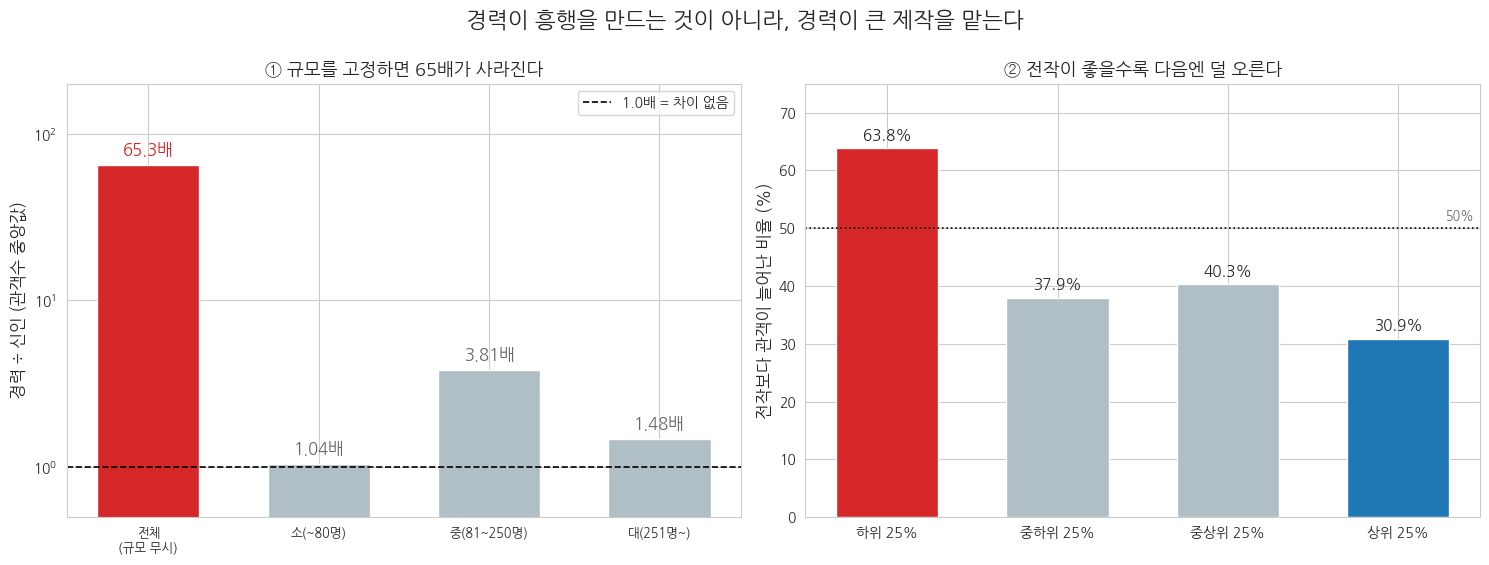

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))

# ── 왼쪽: 규모 고정 전후 배수 ──
ax = axes[0]
배수목록 = []
for 규모 in 규모목록:
    a = df[(df['규모'] == 규모) & (df['감독'] == '경력')]['box_off_num'].median()
    b = df[(df['규모'] == 규모) & (df['감독'] == '신인')]['box_off_num'].median()
    배수목록.append(a / b)

이름 = ['전체\n(규모 무시)'] + 규모목록
값 = [단순.loc['경력', '관객중앙'] / 단순.loc['신인', '관객중앙']] + 배수목록
색 = ['#d62728', '#b0bec5', '#b0bec5', '#b0bec5']

막대 = ax.bar(range(4), 값, color=색, width=0.6)
ax.axhline(1, color='black', linestyle='--', linewidth=1.2, label='1.0배 = 차이 없음')
for i, v in enumerate(값):
    글자 = '%.1f배' % v if v >= 10 else '%.2f배' % v
    ax.text(i, v * 1.15, 글자, ha='center', fontsize=12,
            fontweight='bold', color='#d62728' if i == 0 else '#666')
ax.set_yscale('log')
ax.set_xticks(range(4))
ax.set_xticklabels(이름, fontsize=9)
ax.set_ylim(0.5, 200)
ax.set_ylabel('경력 ÷ 신인 (관객수 중앙값)', fontsize=12)
ax.set_title('① 규모를 고정하면 65배가 사라진다', fontsize=13)
ax.legend(fontsize=10)

# ── 오른쪽: 전작 구간별 성장률 ──
ax = axes[1]
성장률 = 성장표['성장률'].tolist()
색2 = ['#d62728', '#b0bec5', '#b0bec5', '#1f77b4']
ax.bar(range(4), 성장률, color=색2, width=0.6)
ax.axhline(50, color='black', linestyle=':', linewidth=1.2)
ax.text(3.45, 51.5, '50%', fontsize=9, color='#666', ha='right')
for i, v in enumerate(성장률):
    ax.text(i, v + 1.5, '%.1f%%' % v, ha='center', fontsize=11, fontweight='bold')
ax.set_xticks(range(4))
ax.set_xticklabels(성장표.index, fontsize=10)
ax.set_ylim(0, 75)
ax.set_ylabel('전작보다 관객이 늘어난 비율 (%)', fontsize=12)
ax.set_title('② 전작이 좋을수록 다음엔 덜 오른다', fontsize=13)

fig.suptitle('경력이 흥행을 만드는 것이 아니라, 경력이 큰 제작을 맡는다', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

**해석**

`dir_prev_bfnum`의 결측 330개는 `dir_prev_num == 0`인 행과 **정확히 일치한다.**
빠진 값이 아니라 *전작이 없어서 존재할 수 없는 값*이므로 0으로 채우는 것이 타당하다.

단순 비교하면 경력 감독(222,258명)이 신인(3,402명)보다 **65.3배** 높다.
그러나 스태프 수도 216명 대 38명으로 5.7배 차이 난다. 경력 감독은 46.3%가 대규모를 맡지만
신인은 12.1%뿐이다.

**제작 규모를 고정하면 65.3배가 최대 3.81배로 줄고, 소규모에서는 1.04배로 사실상 사라진다.**
관객수를 만든 것은 감독 경력이 아니라 제작 규모이며, **경력은 큰 제작을 맡게 해주는 조건**에 가깝다.

전작이 있는 270편(감독 222명)에서 전작 관객수와 이번 관객수의 상관은 **0.406**이다.
방향은 있으나 예측력은 약하다. 그리고 **수준과 변화는 다르다.** 전작 상위 25%는 이번에도
절대 관객수가 높지만(152만 vs 5,693명) **30.9%만 전작보다 늘었고**, 하위 25%는 63.8%가 늘었다.
전작의 대박에는 실력뿐 아니라 운도 섞여 있고, 운은 다음 작품에 이어지지 않는다(평균회귀).

**다만 이 변수를 그대로 믿기 어렵다.** 3편 이상 등장하는 감독 20명 중 **12명(60%)**은
영화를 낼수록 커져야 할 `dir_prev_num`이 편마다 그대로였다. 홍상수 감독은 7편이 등록돼 있는데
6편이 "전작 0편"이다.

"관객수를 몰라서 세지 않았다"는 설명도 성립하지 않는다. 「지금은맞고그때는틀리다」의
`dir_prev_bfnum`(39,317)은 같은 감독 「자유의 언덕」의 관객수와 **정확히 일치**한다.
같은 방식의 사례가 9건 있다. 즉 이 변수는 **이 데이터 안의 작품을 참조해 만들어졌으면서도
일부만 셌다.**

**한계**: 1~3단계 결론은 "이 변수가 정확하다는 전제 하에" 유효하다. 방향성은 참고할 수 있으나
65.3배·1.04배·0.406 같은 수치는 참고치로 다뤄야 한다. 또 이 확인은 3편 이상 등장하는
20명에게만 가능했고, 1편만 등장하는 감독은 대조할 방법이 없어 실제 문제는 더 클 수 있다.

**보조 지적**: 전작 하위 25%의 전작 관객수 중앙값은 1,047명으로 이미 바닥에 가깝다.
더 떨어질 자리가 없어 63.8%가 성장한 것일 수 있다(바닥 효과).

---

# 10. 상영시간과 스태프 수의 관계 · 황경서

**가설**: 상영시간이 길수록 스태프 수가 많을 것이다. 다만 그 관계가 직선인지는 따로 확인한다.

7번에서 두 변수의 상관이 0.623으로 나왔다. 상관계수는 **직선 관계**만 재므로,
실제 모양이 직선인지 확인한다.

### 1단계. 계산에서 제외할 것 확인

In [61]:
print('스태프 0명인 작품: %d편' % (df['num_staff'] == 0).sum())
d10 = df[df['num_staff'] > 0].copy()
print('분석 대상: %d편' % len(d10))

스태프 0명인 작품: 32편
분석 대상: 568편


### 2단계. 상관계수 — 피어슨과 스피어만

피어슨은 직선 관계를, 스피어만은 **순위 관계**를 잰다.
둘이 비슷하면 변환 방식 때문에 생긴 결과가 아니다.

In [62]:
print('피어슨   %.3f' % d10[['time', 'num_staff']].corr().iloc[0, 1])
print('스피어만 %.3f' % d10[['time', 'num_staff']].corr(method='spearman').iloc[0, 1])

피어슨   0.610
스피어만 0.632


### 3단계. 직선인가 — 구간별로 확인

회귀선을 그리기 전에 **구간을 나눠 중앙값**을 본다.
직선이라면 구간마다 같은 폭으로 늘어야 한다.

In [63]:
d10['시간구간'] = pd.cut(d10['time'], [0, 80, 90, 100, 110, 120, 130, 200],
                      labels=['~80', '81-90', '91-100', '101-110',
                              '111-120', '121-130', '131+'])

구간표 = d10.groupby('시간구간', observed=True).agg(
    편수=('num_staff', 'size'), 스태프중앙=('num_staff', 'median'))
구간표['앞구간대비'] = (구간표['스태프중앙'] / 구간표['스태프중앙'].shift(1)).round(2)
print(구간표.to_string())

          편수  스태프중앙  앞구간대비
시간구간                      
~80       69   17.0    NaN
81-90     88   28.0   1.65
91-100   127   54.0   1.93
101-110  100  154.5   2.86
111-120  104  288.0   1.86
121-130   50  313.0   1.09
131+      30  359.0   1.15


### 시각화

직선을 강제하지 않고 **데이터를 따라가는 곡선(LOWESS)**을 그린다.
`sns.regplot`의 기본값은 직선이라, 로그 축과 함께 쓰면 직선이 휘어 보여 오해를 낳는다.

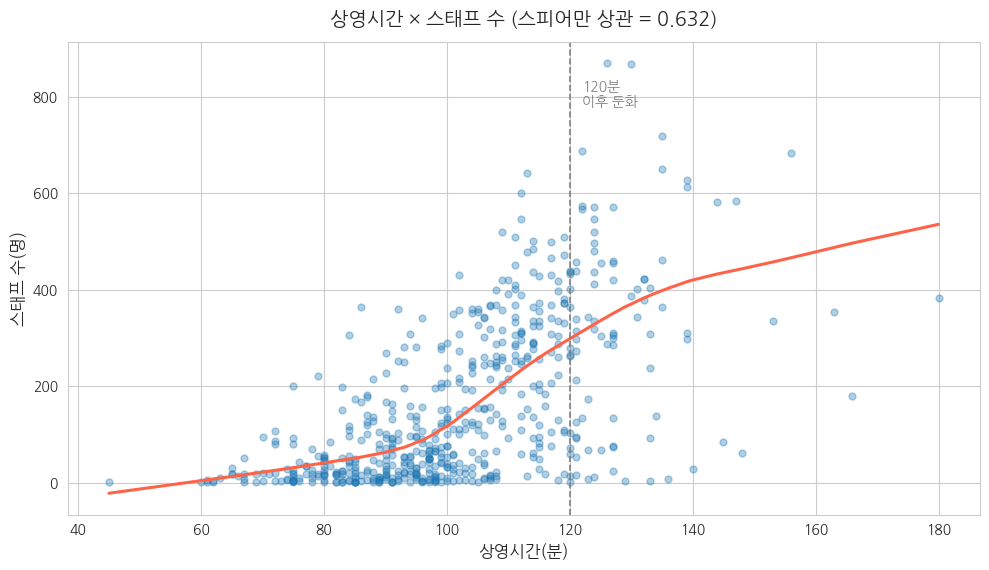

In [64]:
스피어만 = d10[['time', 'num_staff']].corr(method='spearman').iloc[0, 1]

fig, ax = plt.subplots(figsize=(10, 5.8))

sns.regplot(data=d10, x='time', y='num_staff', lowess=True,
            scatter_kws={'alpha': 0.35, 's': 25},
            line_kws={'color': 'tomato', 'linewidth': 2.2}, ax=ax)

ax.axvline(120, color='gray', linestyle='--', linewidth=1.2)
ax.text(122, 780, '120분\n이후 둔화', fontsize=10, color='gray')

ax.set_xlabel('상영시간(분)', fontsize=12)
ax.set_ylabel('스태프 수(명)', fontsize=12)
ax.set_title('상영시간 × 스태프 수 (스피어만 상관 = %.3f)' % 스피어만, fontsize=14, pad=12)
plt.tight_layout()
plt.show()

**해석**

상영시간과 스태프 수는 피어슨 0.623, 스피어만 0.632로 **양의 관계**가 뚜렷하다.
두 값이 비슷하므로 변환 방식 때문에 생긴 결과는 아니다.

다만 **직선은 아니다.** 구간별 스태프 중앙값을 보면 ~80분 17명에서 시작해
101~110분에서 **2.86배**로 가장 가파르게 오르고, **121~130분에서 1.09배로 둔화**된다.
131분 이상도 1.15배에 그친다.

즉 상영시간이 길어질수록 인력이 계속 비례해서 늘어나는 것이 아니라,
**120분 안팎에서 증가세가 꺾인다.** 120분을 넘는 영화는 이미 대규모 제작이라
인력이 포화 상태에 가까운 것으로 보인다.

**한계**: 인과 방향을 알 수 없다. 상영시간이 길어서 인력이 필요한 것인지, 큰 제작이라
애초에 긴 영화를 만드는 것인지 구분되지 않는다. 또 131분 이상 구간은 30편뿐이다.
스태프 0명인 32편은 계산에서 제외했다.

---

# 11. 관람등급 구성은 어떻게 변했는가 · 김희경

**가설**: 청소년 관람불가 영화의 비중이 시간이 지나며 늘었을 것이다.

연도별 전체 구성 → 장르별 변화 → **전체 증가가 구성 때문인지 내부 변화 때문인지**까지 확인한다.

### 0단계. 변수 확인

In [65]:
등급순서 = ['전체 관람가', '12세 관람가', '15세 관람가', '청소년 관람불가']
print('결측:', df['screening_rat'].isna().sum(), '개')
print()
print(df['screening_rat'].value_counts().reindex(등급순서).to_string())
print()
print(df['연도'].value_counts().sort_index().to_string())

결측: 0 개

screening_rat
전체 관람가       92
12세 관람가     102
15세 관람가     202
청소년 관람불가    204

연도
2010     90
2011     80
2012     88
2013     95
2014    127
2015    120


### 1단계. 연도별 관람등급 구성

In [66]:
연도표 = pd.crosstab(df['연도'], df['screening_rat'], normalize='index')[등급순서] * 100
연도표.round(1)

screening_rat,전체 관람가,12세 관람가,15세 관람가,청소년 관람불가
연도,,,,
2010,20.0,17.8,30.0,32.2
2011,23.8,17.5,38.8,20.0
2012,9.1,20.5,50.0,20.5
2013,12.6,13.7,33.7,40.0
2014,14.2,17.3,27.6,40.9
2015,14.2,15.8,27.5,42.5


### 2단계. 장르별 청소년 관람불가 비율의 변화

연도별로 나누면 장르당 편수가 너무 적어, 6개 연도를 절반으로 묶는다.
경계(2012/2013)는 1단계에서 비율이 크게 오른 시점과 일치한다.

In [67]:
df['기간'] = np.where(df['연도'] <= 2012, '2010~2012년', '2013~2015년')

편수표 = pd.crosstab(df['genre'], df['기간']).loc[주요장르]
비율표 = (df.groupby(['genre', '기간'])['청불'].mean().unstack() * 100).loc[주요장르]

변화 = pd.DataFrame({'전기': 비율표['2010~2012년'],
                   '후기': 비율표['2013~2015년'],
                   '변화폭': 비율표['2013~2015년'] - 비율표['2010~2012년'],
                   '전기편수': 편수표['2010~2012년'],
                   '후기편수': 편수표['2013~2015년']})
print(변화.round(1).sort_values('변화폭', ascending=False).to_string())

          전기    후기   변화폭  전기편수  후기편수
genre                               
멜로/로맨스  25.9  76.5  50.5    27    51
코미디      6.9  41.7  34.8    29    24
드라마     26.5  42.9  16.4   102   119
느와르     63.6  68.8   5.1    11    16
다큐멘터리    0.0   1.9   1.9    40    53
공포      53.3  51.9  -1.5    15    27
액션      50.0  28.6 -21.4    14    14


편수가 적어 **피셔 정확검정**으로 확인한다. (카이제곱은 기대빈도가 작을 때 부정확하다)

In [68]:
for 장르 in 주요장르:
    s = df[df['genre'] == 장르]
    전 = s[s['기간'] == '2010~2012년']['청불']
    후 = s[s['기간'] == '2013~2015년']['청불']
    p = stats.fisher_exact([[전.sum(), (~전).sum()], [후.sum(), (~후).sum()]])[1]
    print('%-8s %2d/%3d → %2d/%3d   p = %.4f'
          % (장르, 전.sum(), len(전), 후.sum(), len(후), p))

드라마      27/102 → 51/119   p = 0.0116
다큐멘터리     0/ 40 →  1/ 53   p = 1.0000
멜로/로맨스    7/ 27 → 39/ 51   p = 0.0000
코미디       2/ 29 → 10/ 24   p = 0.0035
공포        8/ 15 → 14/ 27   p = 1.0000
액션        7/ 14 →  4/ 14   p = 0.4401
느와르       7/ 11 → 11/ 16   p = 1.0000


### 3단계. 변화가 가장 큰 멜로/로맨스를 자세히 본다

In [69]:
멜로 = df[df['genre'] == '멜로/로맨스']
멜로표 = 멜로.groupby('연도').agg(편수=('청불', 'size'), 청불수=('청불', 'sum'))
멜로표['비율'] = (멜로표['청불수'] / 멜로표['편수'] * 100).round(1)
print(멜로표.to_string())

      편수  청불수    비율
연도                 
2010  11    5  45.5
2011   7    1  14.3
2012   9    1  11.1
2013  12    7  58.3
2014  18   15  83.3
2015  21   17  81.0


In [70]:
m2014 = 멜로[(멜로['연도'] == 2014) & (멜로['청불'])]
print('2014년 멜로/로맨스 청소년 관람불가: %d편' % len(m2014))
print(m2014[['title', 'num_staff', 'box_off_num']]
      .sort_values('box_off_num').to_string(index=False))

2014년 멜로/로맨스 청소년 관람불가: 15편
            title  num_staff  box_off_num
          젊은 엄마 2          0            1
             러브멘토          0           54
         캠퍼스 S 커플         66          891
   나는 야한 여자가 좋다 2         26         1250
       가자, 장미여관으로         26         1533
              중독애         24         1547
               열애         42         1564
             먹이사슬          0         2070
               관계         57         2146
         여배우는 너무해        129         2673
          여배우 공작단          7         2729
가자! 장미여관으로 2 - 갈증         27         3534
청춘학당 : 풍기문란 보쌈 야사        100         3772
         배꼽과 무릎사이         18         7448
            마담 뺑덕        450       471248


### 4단계. 전체 증가는 장르 구성 때문인가, 장르 내부의 변화인가

청소년 관람불가가 많은 장르가 늘어서인지(**구성의 변화**), 각 장르 안에서 비율이 올라서인지
(**내부의 변화**) 구분한다.

방법: 후기의 **장르별 비율은 그대로 두고 장르 구성만 전기와 같다고 가정**해 전체 비율을
다시 계산한다. 그 값이 전기 실제와 비슷하면 구성 때문이고, 후기 실제와 비슷하면 내부 변화 때문이다.

In [71]:
구성비 = pd.crosstab(df['genre'], df['기간'], normalize='columns')
장르별비율 = df.groupby(['genre', '기간'])['청불'].mean().unstack().fillna(0)

전기실제 = df[df['기간'] == '2010~2012년']['청불'].mean() * 100
후기실제 = df[df['기간'] == '2013~2015년']['청불'].mean() * 100
구성고정 = (구성비['2010~2012년'] * 장르별비율['2013~2015년']).sum() * 100

print('2010~2012년 (실제)                        : %.1f%%' % 전기실제)
print('2013~2015년 (장르 구성을 전기와 같게 가정): %.1f%%' % 구성고정)
print('2013~2015년 (실제)                        : %.1f%%' % 후기실제)
print()
print('전체 증가 %.1f%%p 중' % (후기실제 - 전기실제))
print('  구성 효과 : %.1f%%p' % (후기실제 - 구성고정))
print('  내부 효과 : %.1f%%p' % (구성고정 - 전기실제))

2010~2012년 (실제)                        : 24.4%
2013~2015년 (장르 구성을 전기와 같게 가정): 39.0%
2013~2015년 (실제)                        : 41.2%

전체 증가 16.8%p 중
  구성 효과 : 2.2%p
  내부 효과 : 14.6%p


### 시각화

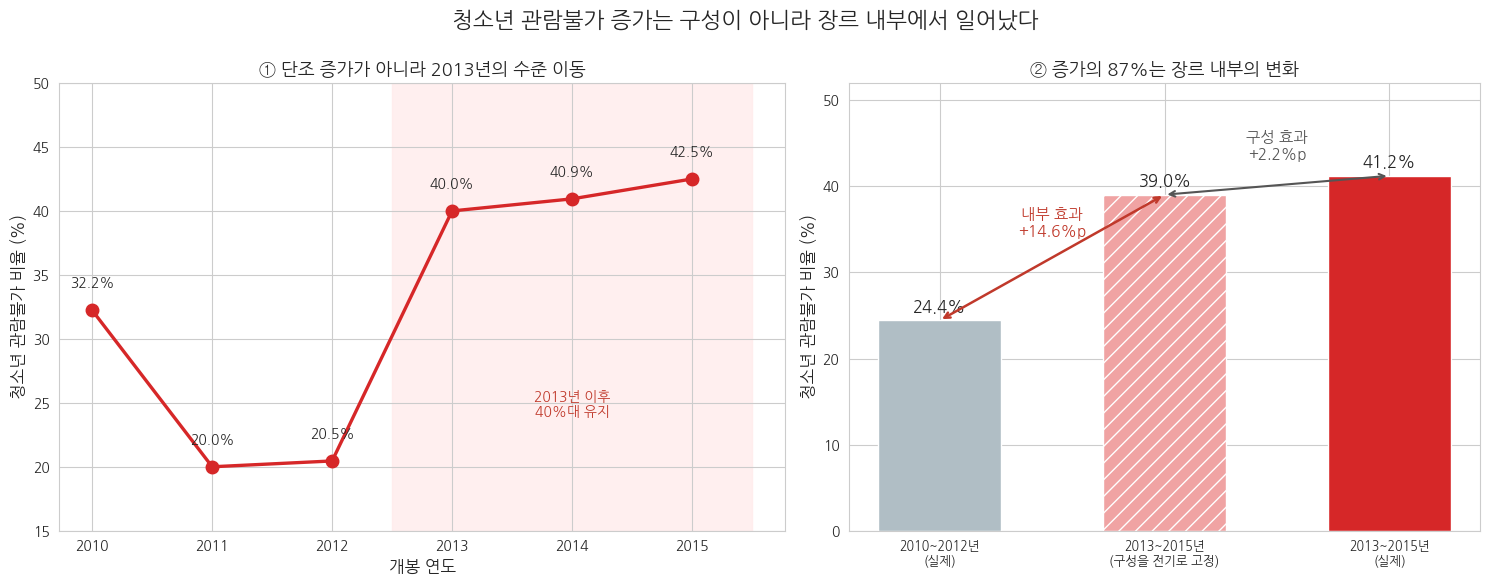

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8),
                         gridspec_kw={'width_ratios': [1.15, 1]})

# ── 왼쪽: 연도별 청불 비율 ──
ax = axes[0]
청불비율 = 연도표['청소년 관람불가']
ax.plot(청불비율.index, 청불비율.values, marker='o', markersize=9,
        linewidth=2.4, color='#d62728')
for 연도, v in zip(청불비율.index, 청불비율.values):
    ax.text(연도, v + 1.8, '%.1f%%' % v, ha='center', fontsize=10, fontweight='bold')
ax.axvspan(2012.5, 2015.5, color='#ffe9e9', alpha=0.7, zorder=0)
ax.text(2014, 24, '2013년 이후\n40%대 유지', fontsize=10, color='#c0392b', ha='center')
ax.set_xticks(청불비율.index)
ax.set_ylim(15, 50)
ax.set_xlabel('개봉 연도', fontsize=12)
ax.set_ylabel('청소년 관람불가 비율 (%)', fontsize=12)
ax.set_title('① 단조 증가가 아니라 2013년의 수준 이동', fontsize=13)

# ── 오른쪽: 구성 효과 vs 내부 효과 ──
ax = axes[1]
값 = [전기실제, 구성고정, 후기실제]
이름 = ['2010~2012년\n(실제)', '2013~2015년\n(구성을 전기로 고정)', '2013~2015년\n(실제)']
막대 = ax.bar(range(3), 값, color=['#b0bec5', '#f0a3a3', '#d62728'], width=0.55)
막대[1].set_hatch('//')                       # 가정값이므로 빗금
for i, v in enumerate(값):
    ax.text(i, v + 1, '%.1f%%' % v, ha='center', fontsize=12, fontweight='bold')

ax.annotate('', xy=(1, 구성고정), xytext=(0, 전기실제),
            arrowprops=dict(arrowstyle='<->', color='#c0392b', lw=1.8))
ax.text(0.5, (전기실제 + 구성고정) / 2 + 2.5, '내부 효과\n+%.1f%%p' % (구성고정 - 전기실제),
        ha='center', fontsize=11, fontweight='bold', color='#c0392b')
ax.annotate('', xy=(2, 후기실제), xytext=(1, 구성고정),
            arrowprops=dict(arrowstyle='<->', color='#555', lw=1.5))
ax.text(1.5, (구성고정 + 후기실제) / 2 + 3, '구성 효과\n+%.1f%%p' % (후기실제 - 구성고정),
        ha='center', fontsize=11, color='#555')

ax.set_xticks(range(3))
ax.set_xticklabels(이름, fontsize=9)
ax.set_ylim(0, 52)
ax.set_ylabel('청소년 관람불가 비율 (%)', fontsize=12)
ax.set_title('② 증가의 87%는 장르 내부의 변화', fontsize=13)

fig.suptitle('청소년 관람불가 증가는 구성이 아니라 장르 내부에서 일어났다',
             fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

**해석**

청소년 관람불가 비율은 **2010년 32.2%로 이미 높았다가** 2011~2012년 20%대로 떨어진 뒤,
2013년부터 40% 이상으로 올라 유지된다(2013년 40.0%, 2014년 40.9%, 2015년 42.5%).
**단조 증가가 아니라 2013년을 경계로 한 수준 이동**이다. 같은 기간 15세 관람가는
2012년 50.0%에서 2015년 27.5%로 줄었다.

이 증가는 모든 장르에서 나타나지 않았다. **멜로/로맨스(25.9% → 76.5%, +50.5%p)**,
코미디(+34.8%p), 드라마(+16.4%p)에 집중됐고, 피셔 정확검정에서도 세 장르만 유의하다
(각각 p<0.001, 0.004, 0.012). 공포·느와르는 원래 높은 수준에서 변화가 없었다.

멜로/로맨스를 연도별로 보면 2011~2012년에 11~14%로 낮았다가 2013년 58.3%,
**2014년 18편 중 15편(83.3%)**, 2015년 21편 중 17편(81.0%)으로 높게 유지된다.
2014년 15편의 제목과 관객수를 보면 대부분 스태프 한 자릿수에 관객 수천 명대로,
**저예산 성인물 계열**로 추정된다.

**전체 증가는 구성이 아니라 내부 변화 때문이다.** 후기의 장르 구성을 전기와 똑같이
고정해도 비율은 39.0%까지 오르고, 실제 41.2%와 거의 같다. 전체 증가 16.8%p 중
**구성 효과는 2.2%p**에 그치고 나머지 **14.6%p(약 87%)**가 장르 내부의 변화다.

**한계**: 이 데이터의 600편은 전체 개봉작이 아니므로 산업 전체로 일반화할 수 없다.
연도별 편수가 적어 한 해의 비율은 불안정하다(멜로/로맨스는 7~21편). 기간 경계와
그래프의 강조 기준은 결과를 본 뒤 정했으므로 통계적 판정이 아니라 강조를 위한 표시다.
장르는 영화당 하나만 기록되어 있다. 무엇보다 이 분석은 변화가 있었다는 것을 보였을 뿐,
왜 그런 변화가 생겼는지는 이 데이터로 확인할 수 없다.

---

# 종합

열한 개 분석에서 **같은 구조가 반복해서 나타났다.**

## 1. 겉보기 차이의 상당 부분은 제작 규모였다

| 분석 | 겉보기 | 규모를 고정하면 |
|---|---|---|
| 1. 수요일 개봉 | 173배 | 소 1.2배 · 대 1.9배 |
| 2. 1월 개봉 | 24배 | 소 1.7배 · 대 1.15배 |
| 9. 감독 경력 | 65.3배 | 소 1.04배 · 대 1.48배 |
| 7. 상영시간 상관 | 0.598 | 0.256 |

개봉 요일·개봉 월·감독 경력·상영시간은 모두 **규모의 그림자**를 일부 지니고 있었다.
제작 규모(스태프 수)만으로 관객수 흩어짐의 **56.2%**가 설명된다(5번).

## 2. 묶는 단위를 바꾸면 결론이 바뀐다

- 2번: **계절**로 묶으면 "겨울이 높다"지만, **월**로 쪼개면 1월만 높다
- 6번: **소·중·대 3칸**이면 효율이 단조 증가로 보이지만, **10분위**로 쪼개면 문턱이 보인다
- 3번: **"5의 배수"**로만 보면 원인을 모르지만, **끝자리 10개**로 펼치면 0과 5가 함께 솟는다

## 3. 비교 대상을 맞추지 않으면 착시가 생긴다

- 8번: 장르 구성을 안 맞추면 소규모 45배 → 맞추면 **3.1배**
- 7번: 결측을 0으로 채운 330편이 상관을 0.448로 끌어올림 → 270편만 보면 **0.409**
- 11번: 장르 구성을 고정해도 39.0% → 증가의 **87%**는 내부 변화

## 4. 데이터가 만들어진 방식도 결과에 남는다

- 3번: 작은 영화일수록 상영시간을 **반올림해서 기재**한 흔적
- 9번: `dir_prev_num`이 같은 데이터 안의 작품을 참조하면서도 **일부만 셈**(9건 확인)

## 공통 한계

- **제작비 변수가 없어** 스태프 수를 제작 규모의 대리 지표로 썼다
- **모든 결과는 상관이지 인과가 아니다.** 인력이 흥행을 만든 것인지, 흥행이 예상되는
  작품에 인력이 투입된 것인지 이 데이터로는 가릴 수 없다
- 대형 배급사 비율이 스태프 수와 함께 오르기 때문에(6% → 81%)
  **제작 규모와 배급 체급은 분리되지 않는다**
- 600편은 전체 개봉작이 아니므로 산업 전체로 일반화할 수 없다